# A Transformer, One Sentence at a Time
## Waiting for the next token at Oracle Park

**LLM Basic / Hands-on 01 / English edition**  
Follow real GPT-2 weights from a string of text to the next token, through small, inspectable experiments.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/trinashih/LLM_Basic/blob/main/notebooks/transformer_one_sentence_en.ipynb)

Language: [English](https://github.com/trinashih/LLM_Basic/blob/main/notebooks/transformer_one_sentence_en.ipynb)

> At Oracle Park, Trina asked the old oracle whether Oracle Linux would boot before the database demo.

A stadium, a prophet, and a Linux distribution: related spellings in different contexts. First explore the embedding neighborhood of `Linux`, then take this sentence apart.

| Route | What you will inspect |
| :--- | :--- |
| **Before Transformer** | The problems N-grams, RNNs, and LSTMs solved, and the constraints they left |
| **Text becomes numbers** | Tokenization, IDs, embeddings, neighbors, 2D / 3D projections |
| **Inside the sentence** | Position, Q / K / V, causal masking, multi-head attention, FFN, Add & Norm |
| **The next token** | Contextual states, logits, softmax, loss, and step-by-step generation |
| **Side trips** | The original architecture figure, cross-attention, BERT, BertViz, Projector, and the bridge to RAG |

### Getting started
1. Open in Colab and execute from the top. CPU works; GPU is optional.
2. The first run downloads public model weights: about 0.5 GB for GPT-2. No API key or training is needed.
3. Edit the `@param` controls and rerun that cell. After changing the model or main sentence, rerun the cells below it too.
4. BERT, BertViz, and 3D are optional and initially disabled. Extra models are not downloaded unless enabled.

**Private repository:** In Colab, use Open notebook → GitHub, connect your GitHub account, and enable access to private repositories. If that does not work, use Download raw file on GitHub to obtain the `.ipynb`, then upload it to Colab. [Colab's GitHub guide](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)

**Our experiment rule:** Tables and figures come from measured results. We will not decide beforehand that Ubuntu must be a neighbor or that one attention head understands companies. GPT-2 is an older, non-chat model; its outputs can be wrong or biased. Do not enter confidential documents.

**Saved previews and validation:** Some cells contain previews measured with default GPT-2 settings on CPU. Rerunning replaces them; a visible preview does not create runtime variables. The source notebook was tested sequentially on CPU. The author's attached Colab GPU run also passed all 13 core checks and produced BERT, BertViz, and 3D outputs. That is evidence for the source version, not a claim that these translated editions have already been run in Colab. Chart labels, code identifiers, and numerical tables remain in English across editions.

## How to read this version

Each section starts with what the previous component still lacks, then introduces the design, runs an experiment, and interprets the result. Equations describe what we do; no memorization is required. Sections 3–11 form the core, and 14–16 lead to prediction and generation. Sections 12–13 connect architecture and context; 17–19 are extensions. On the first run, execute from the top to initialize dependencies.

For every plot, identify the rows, columns, and color quantity. Position coordinates, attention mixing weights, and next-token probabilities are three different things.

## 0. Prepare the workbench

We pin `transformers` to **4.57.6** because this notebook inspects internal module names. The aim is reproducible calculations, not following the newest API. We leave Colab's PyTorch / CUDA installation in place.

We use `eager` attention and float32 to expose the attention matrices explicitly. Speed benchmarking is outside this experiment.

In [ ]:
#@title 0.1 Prepare libraries
import importlib.metadata as metadata
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torch") is None:
    raise RuntimeError("PyTorch is required. Open this notebook in a fresh Colab Python runtime.")
if "transformers" in sys.modules and sys.modules["transformers"].__version__ != "4.57.6":
    raise RuntimeError("A different version is already loaded. Restart the runtime and execute from the top.")

requirements = {
    "transformers": "transformers==4.57.6",
    "numpy": "numpy>=1.26,<3",
    "pandas": "pandas>=2.2,<3",
    "matplotlib": "matplotlib>=3.8,<4",
    "scikit-learn": "scikit-learn>=1.4,<1.8",
    "plotly": "plotly==5.24.1",
    "ipywidgets": "ipywidgets==8.1.7",
    "adjustText": "adjustText==1.3.0",
}
from packaging.requirements import Requirement
missing = []
for package, spec in requirements.items():
    try:
        ok = metadata.version(package) in Requirement(spec).specifier
    except metadata.PackageNotFoundError:
        ok = False
    if not ok:
        missing.append(spec)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Ready:", {p: metadata.version(p) for p in ["torch", *requirements]})

**How to read the result.** When installation finishes without an error, continue. This cell prepares software; it does not load or train the model. The first download can take a while. If a runtime restart is requested, restart and run from the beginning.

In [ ]:
#@title 0.2 Display and reproducibility settings
import gc
import html
import json
import math
import os
import random
import re
import shutil
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch, Rectangle
import torch
import torch.nn.functional as F
from IPython.display import HTML, Markdown, display
from sklearn.decomposition import PCA
from adjustText import adjust_text
from transformers import AutoTokenizer, GPT2LMHeadModel, set_seed

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

ARTIFACTS = Path("transformer_lab_outputs")
ARTIFACTS.mkdir(exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 115, "savefig.dpi": 180, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
})
COLORS = ["#007F73", "#3165B4", "#C13F65", "#52525B"]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=COLORS)
pd.set_option("display.max_colwidth", 95)

def show_table(frame, filename=None):
    display(frame.style.hide(axis="index").format(precision=5))
    if filename:
        frame.to_csv(ARTIFACTS / filename, index=False)

def finish(fig, name):
    fig.savefig(ARTIFACTS / (name + ".png"), bbox_inches="tight")
    plt.show()
    plt.close(fig)

def token_label(token_id):
    value = tokenizer.decode([int(token_id)], clean_up_tokenization_spaces=False)
    return value.replace(" ", "[sp]").replace("\n", "[nl]").replace("\t", "[tab]")

try:
    from google.colab import output as colab_output
    colab_output.enable_custom_widget_manager()
except ImportError:
    pass

print("Device:", DEVICE, "| Seed:", SEED, "| Figures:", ARTIFACTS)

**How to read the result.** `Device` is the CPU or GPU used for computation; either works here. `Seed` fixes the starting point for random operations. `Figures` names the output folder. This cell also defines the plotting helpers, so run it before the experiments.

## 1. Why did we need all these parts?

This is a learning route, not a strict invention timeline. Embedding is an input component used by RNNs and Transformers, not a replacement for them. Attention also predates the 2017 Transformer: it was already used in RNN-based translation. [Bahdanau et al.](https://arxiv.org/abs/1409.0473)

| Method | Problem addressed | Remaining limitation |
| :--- | :--- | :--- |
| N-gram | Count the next word using the previous $n-1$ words | A short fixed window, unseen combinations, sparse counts |
| Embedding | Map discrete IDs to trainable continuous vectors | A standalone input embedding has no occurrence-specific context |
| RNN | Carry information through $h_t=f(x_t,h_{t-1})$ | Sequential dependence; vanishing or exploding gradients along long paths |
| LSTM | Control memory updates with a cell state and gates | Better memory is not unlimited memory; sequential dependence remains |
| Attention | Gather information from relevant positions with learned weights | Weights are not an explanation by themselves; dense matrices are costly for long sequences |
| Transformer | Stack attention and position-wise FFNs without recurrence | Needs positional information; standard dense attention has quadratic sequence-length cost |

At the center of an LSTM is $c_t=f_t\odot c_{t-1}+i_t\odot\tilde c_t$.
The forget gate controls what fraction to retain, the input gate controls what to write, and the output gate controls what to expose.

**Parallelism:** Self-attention can compute all queries for an available sequence together. That is not an effect of multi-head alone. Training and prompt processing can exploit parallelism; ordinary autoregressive generation still chooses not-yet-generated tokens in sequence.

In [ ]:
#@title 1.1 A tiny N-gram: the same ending hides different distant contexts
# This is a deliberately tiny word-level count model, not GPT-2 training data.
toy_corpus = [
    "Oracle Linux would boot", "Oracle Linux would boot",
    "Oracle Linux would run", "The performer would bow",
    "The performer would sing", "The performer would bow",
]
bigrams = defaultdict(Counter)
for sentence in toy_corpus:
    words = sentence.split()
    for previous, following in zip(words, words[1:]):
        bigrams[previous][following] += 1
counts = bigrams["would"]
ngram_df = pd.DataFrame([
    {"next word": word, "count": count, "p(word | would)": count / sum(counts.values())}
    for word, count in counts.most_common()
])
show_table(ngram_df, "01_toy_bigram.csv")
print("Oracle Linux would ->", counts)
print("The performer would ->", counts)
print("Same last word, same distribution. A larger n helps locally, but keeps a fixed window.")

n = 12
row, col = np.indices((n, n))
views = [(col <= row) & (col >= row - 2), col <= row, col <= row, np.ones((n, n), bool)]
titles = ["N-gram window (3 previous)", "RNN / LSTM: reachable via state", "Causal attention: direct access", "Encoder attention: both directions"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, allowed, title in zip(axes.flat, views, titles):
    ax.imshow(allowed, cmap=ListedColormap(["#F1F3F5", "#007F73"]), vmin=0, vmax=1)
    ax.set(title=title, xlabel="Context token position", ylabel="State after input at position")
    ax.set_xticks([0, 5, 11]); ax.set_yticks([0, 5, 11])
finish(fig, "01_context_access")

**Read the table first, then the diagram.** This tiny model counts what followed the previous word. The same `would` gets the same continuation statistics even when the earlier context concerns Linux or a performer. Connections in the diagram show which positions a design can access, not measured attention.

A short window loses distant clues. Increasing N extends the window but creates many more combinations, including unseen ones. This is not how GPT-2 is trained.

**What to notice:** These are diagrams of structural access, not measured attention. The RNN triangle means past information can reach the current position through the hidden state; it does not mean every past token is remembered equally well. Each N-gram row shows the window available after reading that position, when predicting the next word.

## 2. Meet GPT-2

**Distinguish three numbers first:** a layer is a processing round; an attention head is one matching-and-mixing computation within it; a dimension is a vector coordinate. Twelve heads are not twelve models or twelve words. Section 7 will unpack their Q/K/V.

**Why a small pretrained model?** We can inspect real learned weights in an ordinary Colab runtime without first training a model.

Standard GPT-2 small has **12 layers / 12 heads / 768 dimensions**. We inspect its outputs without updating its weights. You can select `distilgpt2` for a smaller model, but its neighbors and predictions will differ.

We pin the model and tokenizer revisions and record the run environment. [GPT-2 model card](https://huggingface.co/openai-community/gpt2) / [Implementation reference](https://huggingface.co/docs/transformers/v4.57.3/model_doc/gpt2)

In [ ]:
#@title 2.1 Choose and load the model
MODEL_CHOICE = "gpt2" #@param ["gpt2", "distilgpt2"]
CHECKPOINTS = {
    "gpt2": ("openai-community/gpt2", "607a30d783dfa663caf39e06633721c8d4cfcd7e"),
    "distilgpt2": ("distilbert/distilgpt2", "2290a62682d06624634c1f46a6ad5be0f47f38aa"),
}
MODEL_ID, REVISION = CHECKPOINTS[MODEL_CHOICE]
if "model" in globals():
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=REVISION, use_fast=True, trust_remote_code=False)
model = GPT2LMHeadModel.from_pretrained(
    MODEL_ID, revision=REVISION, use_safetensors=True,
    attn_implementation="eager", trust_remote_code=False,
).to(device=DEVICE, dtype=torch.float32).eval()
model.requires_grad_(False)
cfg = model.config
D, HEADS, LAYERS = cfg.n_embd, cfg.n_head, cfg.n_layer
HEAD_DIM = D // HEADS

manifest = {
    "model": MODEL_ID, "revision": REVISION, "device": DEVICE,
    "dtype": str(next(model.parameters()).dtype), "seed": SEED,
    "attention_backend": model.config._attn_implementation,
    "versions": {p: metadata.version(p) for p in ["torch", "transformers", "numpy", "scikit-learn"]},
}
(ARTIFACTS / "environment.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
show_table(pd.DataFrame([
    {"property": "parameters (tied weights counted once)", "value": f"{model.num_parameters():,}"},
    {"property": "layers / heads / head dimension", "value": f"{LAYERS} / {HEADS} / {HEAD_DIM}"},
    {"property": "vocabulary / embedding / max positions", "value": f"{cfg.vocab_size} / {D} / {cfg.n_positions}"},
    {"property": "position / normalization / FFN activation", "value": "learned absolute / pre-LN / " + cfg.activation_function},
]))
print(MODEL_ID, REVISION)

**What do the numbers mean?** Default GPT-2 has about 50,000 vocabulary entries: token types, not a count of words it understands. Each token has 768 coordinates. There are 12 processing layers, with 12 attention heads in each layer. We load trained weights, without training again. DistilGPT2 has a different layer count.

## 3. String → token → ID

**Start with a problem: how can a computer receive a sentence?**

Split text into addressable pieces, then look up their vectors. A dictionary of complete words struggles with rare and new words; subword and byte combinations let a finite vocabulary represent many strings.

**What we will check:** splitting and reconstructing a sentence, and how spaces and case change pieces. This solves text representation, not meaning yet.

**Tokenization** splits text and assigns IDs. **Embedding** maps IDs to vectors. GPT-2 uses byte-level BPE: words and tokens do not have a one-to-one relationship, and spaces and capitalization are part of the input.

Changing `Oracle` to `oracle` does not make the tokenizer flag a typo. It may produce different IDs or a different number of pieces. A raw-token symbol such as `Ġ` represents a space; it was not literally present in the source sentence.

In [5]:
#@title 3.1 Inspect the sentence token by token
TEXT = "At Oracle Park, Trina asked the old oracle whether Oracle Linux would boot before the database demo." #@param {type:"string"}
encoded = tokenizer(TEXT, return_tensors="pt", return_offsets_mapping=True, add_special_tokens=False)
offsets = encoded.pop("offset_mapping")[0].tolist()
inputs = {k: v.to(DEVICE) for k, v in encoded.items()}
ids = inputs["input_ids"][0].tolist()
T = len(ids)
if not 2 <= T <= 96:
    raise ValueError("Use a sentence of 2 to 96 tokens for this visualization; this is separate from the model's context limit.")
assert tokenizer.decode(ids, clean_up_tokenization_spaces=False) == TEXT
labels = [f"{i}: {token_label(t)}" for i, t in enumerate(ids)]
token_df = pd.DataFrame([
    {"position": i, "raw BPE": tokenizer.convert_ids_to_tokens(t), "decoded piece": repr(tokenizer.decode([t])),
     "ID": t, "character span": f"{a}:{b}", "source slice": repr(TEXT[a:b])}
    for i, (t, (a, b)) in enumerate(zip(ids, offsets))
])
chips = []
for i, t in enumerate(ids):
    color = COLORS[i % len(COLORS)]
    chips.append(f'<span style="border-bottom:3px solid {color};padding:7px 9px;background:#F4F6F7;border-radius:4px">'
                 f'<code>{html.escape(repr(tokenizer.decode([t])))}</code><small style="display:block;color:#52525B">{i} / ID {t}</small></span>')
display(HTML('<div style="display:flex;flex-wrap:wrap;gap:7px;line-height:1.5">' + "".join(chips) + '</div>'))
print(f"{len(TEXT)} characters -> {T} tokens. IDs are labels, not semantic magnitudes.")
show_table(token_df, "03_tokens.csv")

100 characters -> 21 tokens. IDs are labels, not semantic magnitudes.


position,raw BPE,decoded piece,ID,character span,source slice
0,At,'At',2953,0:2,'At'
1,ĠOracle,' Oracle',18650,2:9,' Oracle'
2,ĠPark,' Park',3250,9:14,' Park'
3,",","','",11,14:15,"','"
4,ĠTr,' Tr',833,15:18,' Tr'
5,ina,'ina',1437,18:21,'ina'
6,Ġasked,' asked',1965,21:27,' asked'
7,Ġthe,' the',262,27:31,' the'
8,Ġold,' old',1468,31:35,' old'
9,Ġor,' or',393,35:38,' or'


**One row is one token.** Read down the positions and join the pieces to recover the sentence. `[sp]` displays a real space; those four letters are not fed to the model. IDs are lookup addresses: nearby numbers do not imply nearby meanings. Trina or oracle may span several rows, so a token is not necessarily a word.

The default sentence has 21 tokens. Editing it changes the count and the later plots.

In [ ]:
#@title 3.2 Capitalization, leading spaces, boot / boots
variants = ["Oracle", "oracle", " Oracle", " oracle", "Oracle Park", "Oracle Linux", "oracle Linux",
            "Linux", " Linux", "boot", " boot", "boots", " boots", "AMD", " AMD", "NVMe", " NVMe"]
variant_df = pd.DataFrame([
    {"input (repr)": repr(s), "count": len(tokenizer.encode(s, add_special_tokens=False)),
     "IDs": tokenizer.encode(s, add_special_tokens=False), "raw BPE": tokenizer.tokenize(s)}
    for s in variants
])
show_table(variant_df, "03_case_and_spaces.csv")

**Compare `Oracle`, `oracle`, ` Oracle`, and ` oracle`.** Leading spaces and case can change both token IDs and the number of pieces. This is tokenization, not spell-checking; lowercase is not automatically a mistake. Compare `boot` and `boots` too: an added letter need not become a separate `s` token. Identify the actual pieces before discussing meaning.

## 4. The first surprise: who lives near Linux?

**Start with a problem: why add embeddings after IDs?**

An ID is only an address. A larger Linux ID does not mean “more technical.” Trainable numerical vectors let the model learn relationships through shared features instead of treating IDs only as unrelated labels.

**What we will check:** 4.1 retrieves a vector row; 4.2 finds Linux neighbors using all coordinates; 4.3 compresses them into a map. Understand the lookup before reading the map.

The embedding table is $E\in\mathbb{R}^{|V|\times d}$. Row $E_i$ is the input vector for ID $i$. You could write this as a one-hot vector multiplied by a matrix; implementations use an efficient lookup.

Coordinates do not come with labels such as "cute," "OS," or "company." They are multidimensional features learned through the training objective. Related tokens may have nearby vectors, but spelling, frequency, and spaces can also affect the geometry.

Start with **` Linux`, including the leading space used within a sentence**. If the input splits into multiple tokens, select the piece you want to inspect. We do not silently average pieces and call that a word embedding.

**Execution order:** Run 0.1 / 0.2 and 2.1 first. Cell 4.1 rebuilds sentence inputs, so you can skip the token table in 3.1. It uses an existing `TEXT` value, or the default Oracle sentence if none is set. Saved previews do not initialize runtime variables.

Embedding table: (50257, 768)
This sentence:   (1, 21, 768) = [batch, tokens, dimensions]


d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d13,d14,d15
0.07768,-0.01753,0.06448,-0.03187,-0.10337,0.00296,-0.21805,-0.13477,0.00323,-0.00959,0.02314,0.07368,-0.03951,0.02841,0.03334,-0.03330
0.22095,0.05870,0.19103,-0.08189,-0.10079,-0.09771,-0.22921,-0.00402,-0.08292,-0.05562,0.22938,0.08517,0.09611,0.13221,-0.13603,0.02024
0.21285,0.03045,0.22116,0.05960,-0.17156,-0.11093,-0.22707,-0.07408,-0.00391,-0.00215,0.11237,-0.01716,-0.05579,0.00305,-0.07409,0.02532
0.01150,-0.00295,0.03231,0.05518,0.05239,-0.06036,-0.23997,-0.01733,0.03884,0.04029,-0.00329,0.01973,-0.02108,-0.00370,-0.01925,0.03727
0.17227,0.16755,0.16506,0.05840,-0.10724,0.08377,-0.22514,-0.06460,-0.03235,0.13331,-0.09531,0.09787,-0.02276,-0.09688,-0.02537,-0.00970
-0.14845,0.11056,0.08006,-0.01394,0.09206,0.06803,-0.28417,-0.02723,0.00913,0.27157,-0.13415,-0.10254,-0.18266,0.09060,-0.02975,0.05084


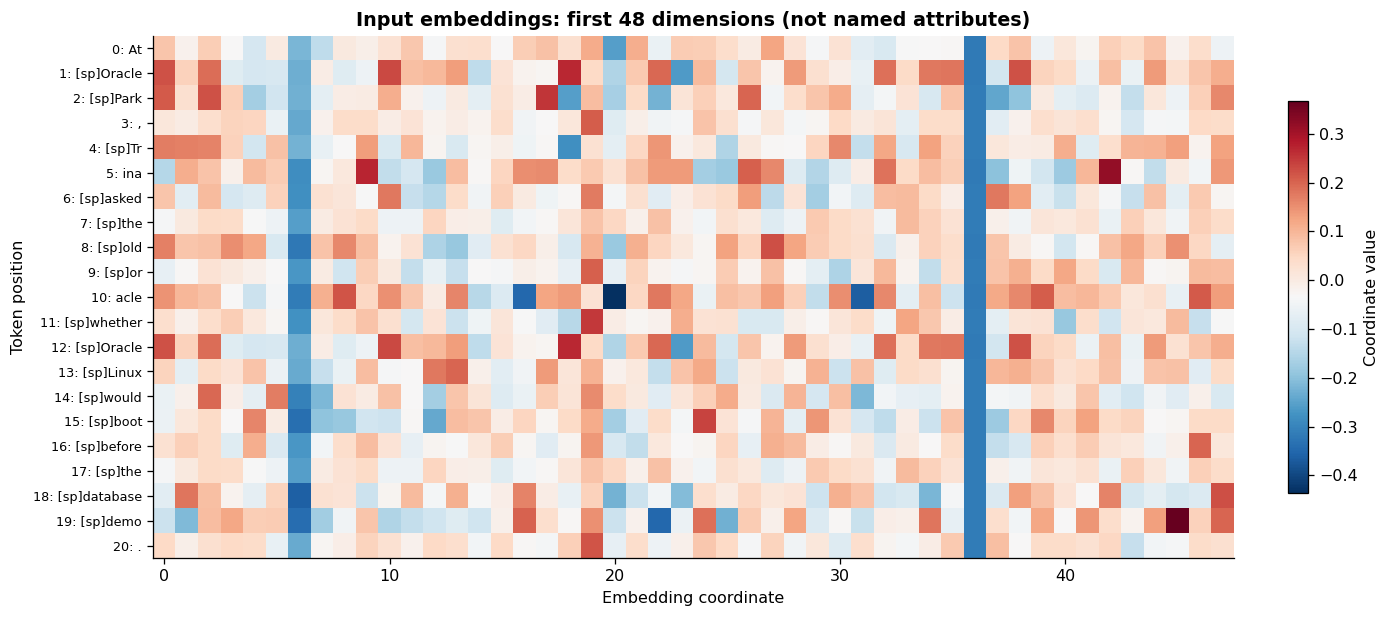

In [ ]:
#@title 4.1 Lookup shapes and the first 16 dimensions
# Rebuild sentence state so this section also works without running the token table.
if "model" not in globals() or "tokenizer" not in globals():
    raise RuntimeError("Run 0.1 / 0.2 and 2.1 (model loading) first.")
TEXT = globals().get(
    "TEXT",
    "At Oracle Park, Trina asked the old oracle whether Oracle Linux would boot before the database demo.",
)
encoded = tokenizer(TEXT, return_tensors="pt", return_offsets_mapping=True, add_special_tokens=False)
offsets = encoded.pop("offset_mapping")[0].tolist()
inputs = {key: value.to(model.device) for key, value in encoded.items()}
ids = inputs["input_ids"][0].tolist()
T = len(ids)
if not 2 <= T <= 96:
    raise ValueError("Use a sentence of 2 to 96 tokens for this visualization.")
assert tokenizer.decode(ids, clean_up_tokenization_spaces=False) == TEXT
labels = [f"{i}: {token_label(token_id)}" for i, token_id in enumerate(ids)]


with torch.inference_mode():
    E = model.transformer.wte.weight.detach().float().cpu()
    token_vectors = model.transformer.wte(inputs["input_ids"])
print("Embedding table:", tuple(E.shape))
print("This sentence:  ", tuple(token_vectors.shape), "= [batch, tokens, dimensions]")
show_table(pd.DataFrame(token_vectors[0, :6, :16].cpu().numpy(), columns=[f"d{i}" for i in range(16)]))

fig, ax = plt.subplots(figsize=(12, max(5, T * .25)), constrained_layout=True)
img = ax.imshow(token_vectors[0, :, :48].cpu(), aspect="auto", cmap="RdBu_r")
ax.set(title="Input embeddings: first 48 dimensions (not named attributes)", xlabel="Embedding coordinate", ylabel="Token position")
ax.set_yticks(range(T), labels, fontsize=8)
fig.colorbar(img, ax=ax, label="Coordinate value", shrink=.75)
finish(fig, "04_embedding_coordinates")

**4.1 Read the shapes before the colors.** With default GPT-2, `(50257, 768)` is the whole lookup table: 50,257 token types, each with 768 numbers. `(1, 21, 768)` means one sentence, 21 tokens, and 768 coordinates per token. It does not mean the sentence became 768 tokens.

Each table row is a token occurrence, showing only its first 16 coordinates. Each heatmap row is also a token; columns are coordinates, with only the first 48 shown. The color bar encodes signed numerical values, **not probabilities, quality, or importance**. No coordinate is assigned a label such as “Linux” or “company.” Meaning is generally distributed across coordinates.

Find the two ` Oracle` occurrences with the same ID: their lookup vectors are identical here, before context is processed. The next section compares neighbors using all 768 coordinates, not visual similarity in these 48 squares.

Query pieces: [(0, '[sp]Linux', 7020)]
Search space: 46892 tokens; filter removes symbols, not semantic noise.


rank,token,ID,cosine
1,Linux,19314,0.77178
2,[sp]linux,32639,0.72484
3,[sp]Ubuntu,14949,0.63533
4,[sp]Unix,33501,0.62955
5,linux,23289,0.62721
6,[sp]Windows,3964,0.60637
7,[sp]GNU,22961,0.59431
8,[sp]Debian,26062,0.58548
9,[sp]FreeBSD,35841,0.58536
10,Windows,11209,0.57767


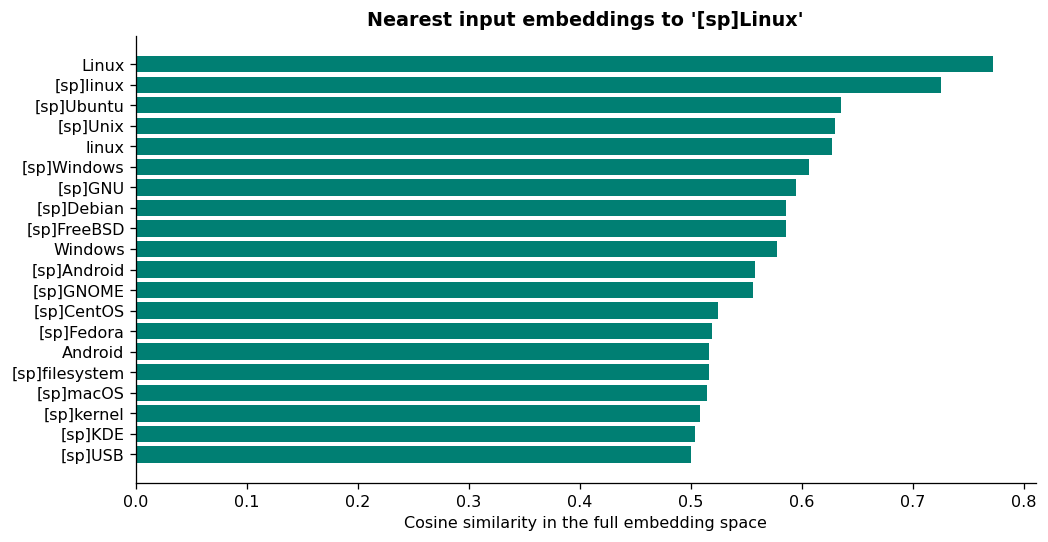

In [8]:
#@title 4.2 Search for neighbors in high dimensions
QUERY_TEXT = "Linux" #@param {type:"string"}
LEADING_SPACE = True #@param {type:"boolean"}
PIECE_INDEX = 0 #@param {type:"integer"}
TOP_K = 20 #@param {type:"slider", min:5, max:40, step:1}
WORDLIKE_ONLY = True #@param {type:"boolean"}
query_text = (" " if LEADING_SPACE else "") + QUERY_TEXT
query_ids = tokenizer.encode(query_text, add_special_tokens=False)
if not 0 <= PIECE_INDEX < len(query_ids):
    raise ValueError(f"Choose PIECE_INDEX from 0 to {len(query_ids)-1}.")
print("Query pieces:", [(i, token_label(t), t) for i, t in enumerate(query_ids)])
query_id = query_ids[PIECE_INDEX]
if len(query_ids) > 1:
    print("Multi-token input: only the selected piece is queried. No word-vector averaging.")

E_unit = F.normalize(E, dim=1)
cosines = E_unit @ E_unit[query_id]
all_decoded = [tokenizer.decode([i], clean_up_tokenization_spaces=False) for i in range(cfg.vocab_size)]
wordlike = torch.tensor([bool(re.fullmatch(r" ?[A-Za-z][A-Za-z0-9_-]*", t)) for t in all_decoded])
allowed = wordlike.clone() if WORDLIKE_ONLY else torch.ones(cfg.vocab_size, dtype=torch.bool)
allowed[tokenizer.all_special_ids] = False
allowed[query_id] = False
search_scores = cosines.clone()
search_scores[~allowed] = -torch.inf
neighbor_ids = torch.topk(search_scores, min(TOP_K, int(allowed.sum()))).indices.tolist()
neighbors_df = pd.DataFrame([
    {"rank": rank, "token": token_label(i), "ID": i, "cosine": cosines[i].item()}
    for rank, i in enumerate(neighbor_ids, 1)
])
show_table(neighbors_df, "04_embedding_neighbors.csv")
print("Search space:", int(allowed.sum()), "tokens; filter removes symbols, not semantic noise.")
fig, ax = plt.subplots(figsize=(9, max(4, TOP_K * .23)), constrained_layout=True)
ax.barh(neighbors_df["token"][::-1], neighbors_df["cosine"][::-1], color=COLORS[0])
ax.set(title=f"Nearest input embeddings to {token_label(query_id)!r}", xlabel="Cosine similarity in the full embedding space")
finish(fig, "04_embedding_neighbors")

**Read the neighbor table from the top.** The query itself is excluded. Cosine closer to 1 means more similar directions. Linux may be near Ubuntu, Unix, and spelling variants. These are learned vector relationships, not search results or hand-made categories.

`LEADING_SPACE` can select a different token. If the text splits into pieces, `PIECE_INDEX=0` selects the first piece, not an average of the word. `TOP_K` controls how many neighbors to display; it is separate from sampling top-k later.

### 4.3 Make a map, but remember what it leaves out

Neighbor rankings use **cosine similarity in the original high-dimensional space**. The PCA plot projects selected L2-normalized vectors into two dimensions. Distances in the plot do not perfectly preserve the original geometry, and the axes do not mean "technical" or "corporate."

Gray points are manually chosen comparison tokens; green points are retrieved neighbors; red is the query. We explicitly distinguish comparison points instead of presenting them as automatically discovered neighbors.

$\displaystyle \operatorname{cos}(u,v)=\frac{u\cdot v}{\|u\|\|v\|}$

Variance retained in 2D: 18.2%
Comparison words skipped because they split: [('oracle', ['[sp]or', 'acle'])]


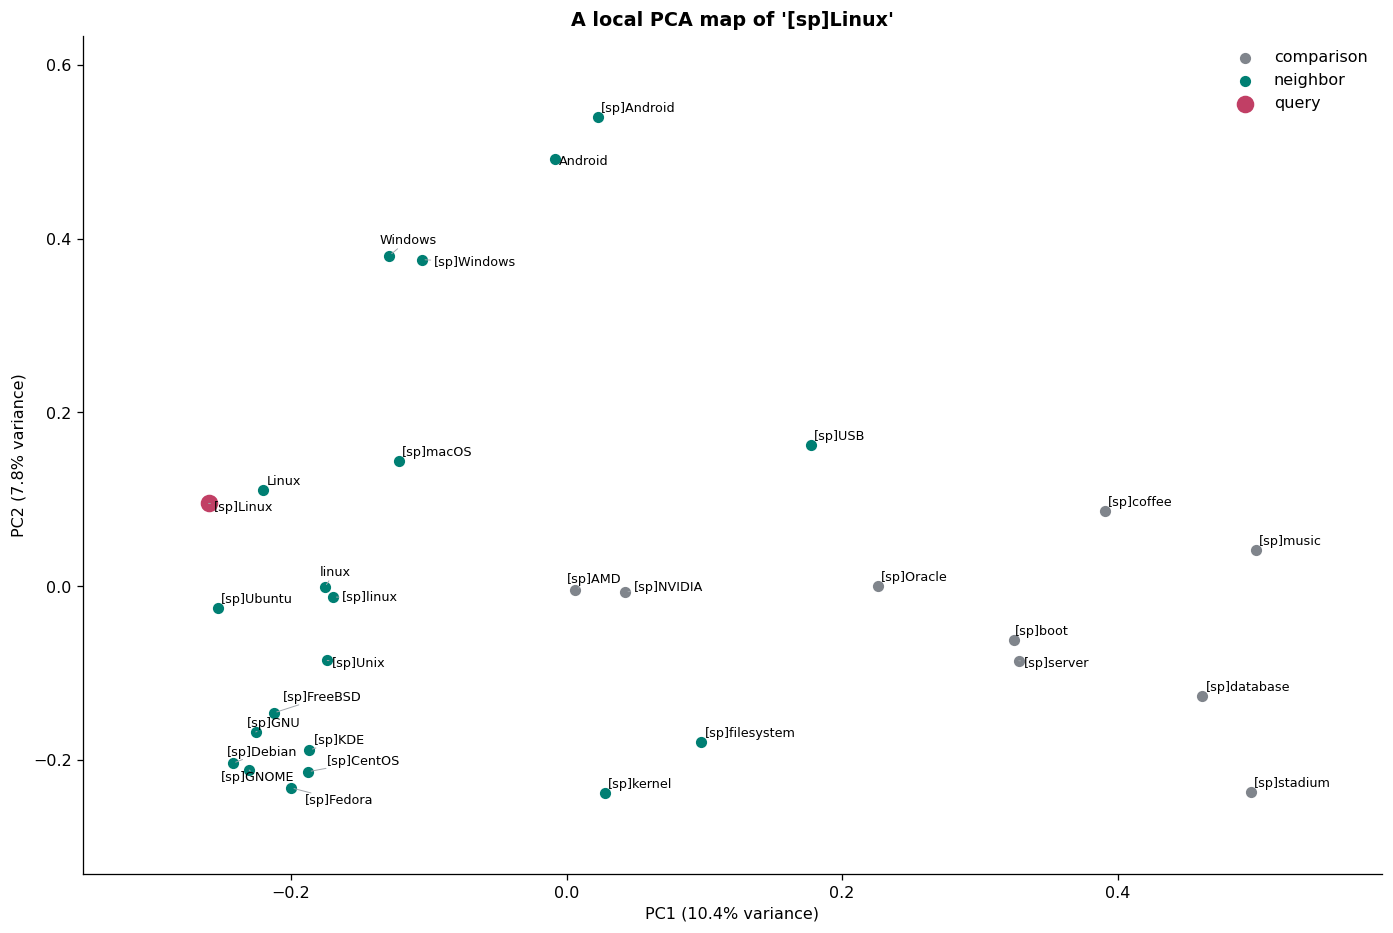

In [9]:
#@title 4.3 A 2D map of the neighborhood
comparison_words = ["Linux", "Windows", "Unix", "Ubuntu", "Debian", "kernel", "database", "server",
                    "Oracle", "oracle", "AMD", "NVIDIA", "boot", "coffee", "music", "stadium"]
comparison_ids = []
skipped_words = []
for word in comparison_words:
    parts = tokenizer.encode(" " + word, add_special_tokens=False)
    if len(parts) == 1:
        comparison_ids.append(parts[0])
    else:
        skipped_words.append((word, [token_label(t) for t in parts]))
map_ids = list(dict.fromkeys([query_id, *neighbor_ids, *comparison_ids]))
map_vectors = E_unit[map_ids].numpy()
pca = PCA(n_components=3, svd_solver="full")
coords = pca.fit_transform(map_vectors)
map_df = pd.DataFrame({
    "ID": map_ids, "token": [token_label(t) for t in map_ids],
    "PC1": coords[:, 0], "PC2": coords[:, 1], "PC3": coords[:, 2],
    "cosine to query": [cosines[t].item() for t in map_ids],
    "group": ["query" if t == query_id else "neighbor" if t in neighbor_ids else "comparison" for t in map_ids],
})
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
for group, color in [("comparison", "#80858C"), ("neighbor", COLORS[0]), ("query", COLORS[2])]:
    subset = map_df[map_df["group"] == group]
    ax.scatter(subset.PC1, subset.PC2, label=group, color=color, s=100 if group == "query" else 36)
map_texts = [ax.text(row.PC1, row.PC2, row["token"], fontsize=8) for _, row in map_df.iterrows()]
ax.margins(.12)
ax.set(title=f"A local PCA map of {token_label(query_id)!r}",
       xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(frameon=False)
np.random.seed(SEED)
adjust_text(map_texts, x=coords[:, 0], y=coords[:, 1], ax=ax,
            expand=(1.15, 1.3), force_text=(.3, .5), iter_lim=300,
            arrowprops=dict(arrowstyle="-", color="#A0A5AB", lw=.6))
finish(fig, "04_embedding_pca")
map_df.to_csv(ARTIFACTS / "04_embedding_pca.csv", index=False)
print("Variance retained in 2D:", f"{pca.explained_variance_ratio_[:2].sum():.1%}")
print("Comparison words skipped because they split:", skipped_words)

**Each dot is a token, not a sentence.** This map compresses 768 dimensions into two. PC1 and PC2 are directions computed from the data, not axes called “technology” or “meaning.” Colors are groups we supplied.

Explore which dots surround Linux, but nearby dots on this projection need not be nearest in the original space. A low explained-variance ratio means much information was omitted. Use the full-dimensional cosine ranking in 4.2 to check neighbors.

In [ ]:
#@title 4.4 Optional: a rotatable 3D map
SHOW_3D = False #@param {type:"boolean"}
if SHOW_3D:
    import plotly.express as px
    fig3d = px.scatter_3d(
        map_df, x="PC1", y="PC2", z="PC3", color="group", hover_name="token",
        hover_data=["ID", "cosine to query"], template="plotly_white",
        color_discrete_map={"query": COLORS[2], "neighbor": COLORS[0], "comparison": "#80858C"},
        title="Input embeddings / PCA projection, not the full geometry",
    )
    fig3d.update_layout(height=600, margin=dict(l=0, r=0, b=0, t=55))
    fig3d.show()
    fig3d.write_html(str(ARTIFACTS / "04_embedding_3d.html"), include_plotlyjs=True)
else:
    print("Optional 3D skipped. The 2D map and full-space neighbor table remain available.")

**A skipped message is normal.** Set `SHOW_3D=True` and rerun to get the rotatable plot. Drag to rotate and hover to identify tokens. The third axis adds a viewing dimension, but this is still a projection of 768 dimensions, not a complete map of meaning.

## 5. Embeddings are a starting point. Where does position come from?

**Start with a problem: how can the same words change who asks whom?**

`Trina asked the old oracle.` and `the old oracle asked Trina.` use the same words but switch the asker. A token embedding depends only on its ID, not its current position. GPT-2 therefore adds a position vector before the first layer.

**Read 5.1 in this order:** ① the swapped-role illustration; ② the same real token vector E plus two position vectors P, producing different E+P; ③ only then the full position-table heatmaps. Their colors encode numbers, not subject roles.

Position supplies a learnable clue, not a grammar label. It is not a repair for multi-head scrambling the sentence.

> Trina asked the old oracle.  
> The old oracle asked Trina.

The asker and the person being asked switch roles. A similar set of words is not enough. Without positional information or masking, self-attention is **permutation equivariant**: permuting inputs permutes the outputs in the same way. Multi-head does not destroy the order.

The original paper uses sine and cosine:

$$PE_{p,2i}=\sin\left(p/10000^{2i/d}\right),\qquad PE_{p,2i+1}=\cos\left(p/10000^{2i/d}\right)$$

**GPT-2 uses learned absolute position embeddings instead.** We show both to keep the distinction clear. Its actual input is $h^{(0)}_p=E_{x_p}+P_p$.

The causal mask also supplies directional structure. Removing position embeddings alone does not turn GPT-2 into a completely unordered bag of words. [Original paper §3.5](https://arxiv.org/html/1706.03762v7#S3.SS5)

E[token] (1, 21, 768) + P[position] (1, 21, 768) = h0 (1, 21, 768)


**① Start with order:** colors track the same people. Roles are human annotations, not model predictions.

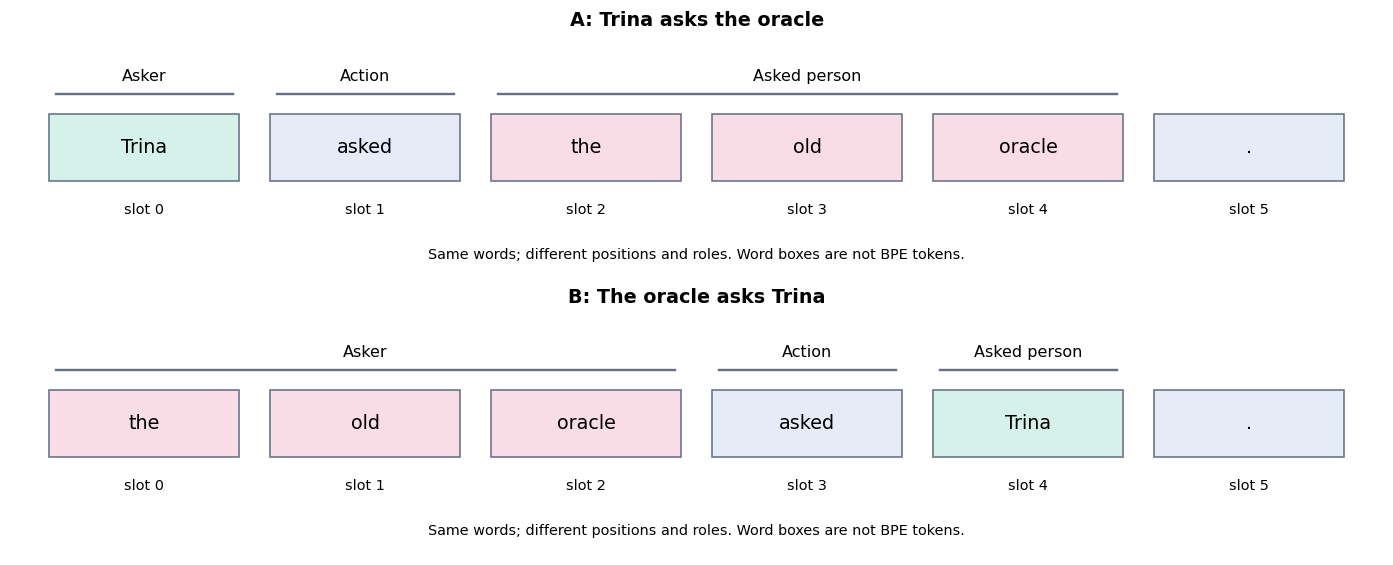

**② Inspect the actual input numbers:** keep one token fixed and change only position. E has identical rows; P has different rows; E+P therefore differs. Pick a coordinate and check E+P in the table below. Only eight coordinates are displayed on one shared color scale. Coordinates have no assigned semantic names.

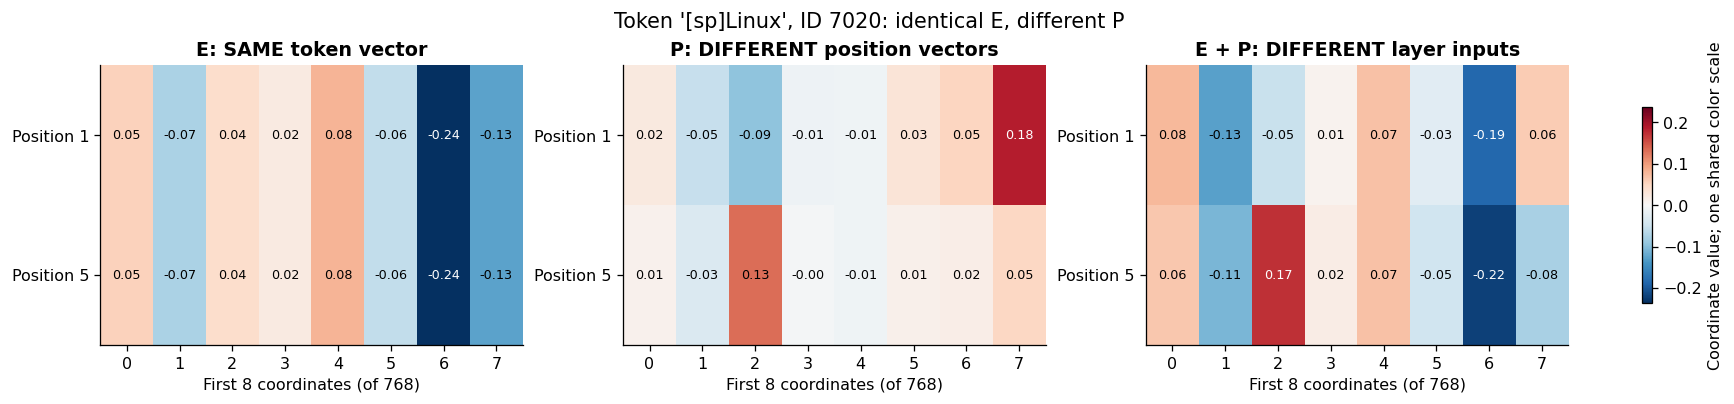

position,coordinate,E (same token),P (position),E + P
1,0,0.05354,0.02396,0.07750
1,1,-0.07393,-0.05379,-0.12772
1,2,0.04182,-0.09488,-0.05306
1,3,0.02104,-0.01291,0.00813
5,0,0.05354,0.00960,0.06314
5,1,-0.07393,-0.03389,-0.10781
5,2,0.04182,0.13123,0.17305
5,3,0.02104,-0.00385,0.01719


**③ Only now inspect the position tables:** rows are positions, columns are coordinates, and the color bar maps numbers to colors. Left is a 48-dimensional sinusoidal illustration; right is the first 48 coordinates of real GPT-2 positions. These are not before/after addition or two sentence interpretations: they compare formula-generated and learned position signals.

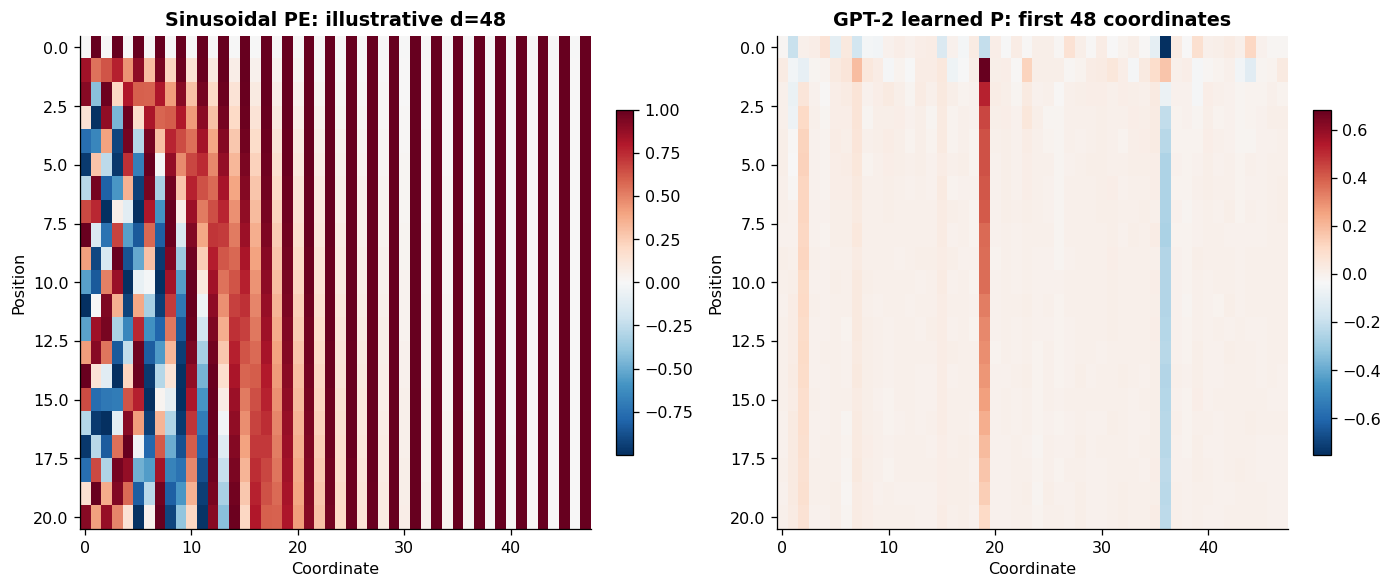

In [ ]:
#@title 5.1 Compare sinusoidal encoding and GPT-2 position embeddings
position_ids = torch.arange(T, device=DEVICE).unsqueeze(0)
with torch.inference_mode():
    position_vectors = model.transformer.wpe(position_ids)
    h0 = model.transformer.drop(token_vectors + position_vectors)


display(Markdown('**① Start with order:** colors track the same people. Roles are human annotations, not model predictions.'))
# Word-level illustration: roles are human annotations, not model predictions.
fig, axes = plt.subplots(2, 1, figsize=(12, 4.8), constrained_layout=True)
for ax, words, role_spans, title in zip(
    axes,
    [["Trina", "asked", "the", "old", "oracle", "."],
     ["the", "old", "oracle", "asked", "Trina", "."]],
    [[(0, 0, "Asker"), (1, 1, "Action"), (2, 4, "Asked person")],
     [(0, 2, "Asker"), (3, 3, "Action"), (4, 4, "Asked person")]],
    ["A: Trina asks the oracle", "B: The oracle asks Trina"],
):
    ax.set(xlim=(-.6, 5.6), ylim=(-.85, 1.15), title=title)
    ax.axis("off")
    for i, word in enumerate(words):
        color = "#D5F1E9" if word == "Trina" else "#F9DDE6" if word in ["the", "old", "oracle"] else "#E5ECF7"
        ax.add_patch(Rectangle((i-.43, -.05), .86, .55, facecolor=color, edgecolor="#667085"))
        ax.text(i, .225, word, ha="center", va="center", fontsize=12)
        ax.text(i, -.32, f"slot {i}", ha="center", fontsize=9)
    for start, end, role in role_spans:
        ax.plot([start-.4, end+.4], [.67, .67], color="#667085")
        ax.text((start+end)/2, .78, role, ha="center", fontsize=10)
    ax.text(2.5, -.69, "Same words; different positions and roles. Word boxes are not BPE tokens.", ha="center", fontsize=9)
finish(fig, "05_word_order_comparison")

display(Markdown('**② Inspect the actual input numbers:** keep one token fixed and change only position. E has identical rows; P has different rows; E+P therefore differs. Pick a coordinate and check E+P in the table below. Only eight coordinates are displayed on one shared color scale. Coordinates have no assigned semantic names.'))

# Actual GPT-2 weights: hold token identity fixed, change position only.
demo_token_id = next((i for i in ids if tokenizer.decode([i]).strip() == "Linux"), ids[0])
demo_positions = [1, 5] if T > 5 else [0, T-1]
with torch.inference_mode():
    demo_e = model.transformer.wte(torch.tensor([demo_token_id], device=DEVICE)).repeat(2, 1)
    demo_p = model.transformer.wpe(torch.tensor(demo_positions, device=DEVICE))
    demo_sum = demo_e + demo_p
assert torch.equal(demo_e[0], demo_e[1])
assert not torch.equal(demo_sum[0], demo_sum[1])
assert torch.allclose(demo_sum[1]-demo_sum[0], demo_p[1]-demo_p[0], atol=1e-6)
demo_matrices = [v[:, :8].float().cpu().numpy() for v in [demo_e, demo_p, demo_sum]]
limit = max(abs(v).max() for v in demo_matrices)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), constrained_layout=True)
for ax, matrix, title in zip(axes, demo_matrices,
    ["E: SAME token vector", "P: DIFFERENT position vectors", "E + P: DIFFERENT layer inputs"]):
    im = ax.imshow(matrix, aspect="auto", cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_xticks(range(8), [str(i) for i in range(8)])
    ax.set_yticks([0, 1], [f"Position {p}" for p in demo_positions])
    ax.set(title=title, xlabel="First 8 coordinates (of 768)")
    for row in range(2):
        for col in range(8):
            ax.text(col, row, f"{matrix[row,col]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(matrix[row,col]) > .6*limit else "black")
fig.suptitle(f"Token {token_label(demo_token_id)!r}, ID {demo_token_id}: identical E, different P", fontsize=13)
fig.colorbar(im, ax=axes, shrink=.7, label="Coordinate value; one shared color scale")
finish(fig, "05_same_token_different_position")
demo_table = pd.DataFrame([
    {"position": pos, "coordinate": dim, "E (same token)": demo_e[row,dim].item(),
     "P (position)": demo_p[row,dim].item(), "E + P": demo_sum[row,dim].item()}
    for row, pos in enumerate(demo_positions) for dim in range(4)
])
show_table(demo_table, "05_position_addition.csv")

display(Markdown('**③ Only now inspect the position tables:** rows are positions, columns are coordinates, and the color bar maps numbers to colors. Left is a 48-dimensional sinusoidal illustration; right is the first 48 coordinates of real GPT-2 positions. These are not before/after addition or two sentence interpretations: they compare formula-generated and learned position signals.'))
p = np.arange(T)[:, None]
even_dims = np.arange(0, 48, 2)
angles = p / (10000 ** (even_dims[None, :] / 48))
sinusoidal = np.zeros((T, 48))
sinusoidal[:, 0::2], sinusoidal[:, 1::2] = np.sin(angles), np.cos(angles)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, matrix, title in zip(axes, [sinusoidal, position_vectors[0, :, :48].cpu().numpy()],
                             ["Sinusoidal PE: illustrative d=48", "GPT-2 learned P: first 48 coordinates"]):
    im = ax.imshow(matrix, aspect="auto", cmap="RdBu_r")
    ax.set(title=title, xlabel="Coordinate", ylabel="Position")
    fig.colorbar(im, ax=ax, shrink=.7)
finish(fig, "05_position_embeddings")
print("E[token]", tuple(token_vectors.shape), "+ P[position]", tuple(position_vectors.shape), "= h0", tuple(h0.shape))



**Take away one result from 5.1: the same token at a different position enters the model with a different vector.**

Check the identical E rows, then compare E+P at coordinate 0 for the two positions. The difference comes exactly from P; the code checks this too. Signed values are not quality, probability, or an asker label.

The final position heatmaps simply stack many P vectors. They are not meant to reveal sentence meaning. Next we test what happens when inputs are permuted with neither position signals nor a causal mask.

Plot annotations are rounded to two decimals, so displayed sums can look slightly inconsistent. The table shows more digits; computations and checks use unrounded values.

In [ ]:
#@title 5.2 Numerical experiment: attention without positions or masking
# A random toy model isolates a mathematical property; these are not GPT-2 weights.
gen = torch.Generator().manual_seed(SEED)
toy_x = torch.randn(5, 8, generator=gen)
toy_wq, toy_wk, toy_wv = [torch.randn(8, 4, generator=gen) for _ in range(3)]
perm = torch.tensor([3, 0, 4, 1, 2])
def toy_attention(x):
    q, k, v = x @ toy_wq, x @ toy_wk, x @ toy_wv
    return torch.softmax(q @ k.T / 2, dim=-1) @ v
permutation_error = (toy_attention(toy_x[perm]) - toy_attention(toy_x)[perm]).abs().max().item()
toy_position = torch.randn(5, 8, generator=gen)
position_error = (toy_attention(toy_x[perm] + toy_position) - toy_attention(toy_x + toy_position)[perm]).abs().max().item()
print("No position / no mask; max permutation error:", permutation_error)
print("Fixed positions added; max error:", position_error)
assert permutation_error < 1e-5

**The near-zero error is the key result.** Permuting the inputs before computation gives almost the same result as computing first and permuting the outputs. Outputs follow the permutation; they are not all identical.

This toy attention, with neither position signals nor a causal mask, cannot identify order on its own. It is not full GPT-2, and multi-head did not cause the problem.

## 6. Run the whole path once

**Start with a problem: what happens to the vectors inside the model?**

Capture the full path so that later manual calculations can be checked against it. For now, identify shapes; you need not interpret every number.

**Meet the head first:** an attention head is one Q/K matching and weighted-V mixing computation. A layer can contain several. Layer selects the processing round, head selects a computation within that round, and token position selects a piece of the sentence.

One forward pass returns hidden states and attention for every position. **Even when the entire sentence is supplied, the causal mask blocks access to its right-hand side at each position.** We will verify this numerically later.

In [ ]:
#@title 6.1 Inspect intermediate states
with torch.inference_mode():
    outputs = model(**inputs, output_attentions=True, output_hidden_states=True, use_cache=False, return_dict=True)
attentions = tuple(a.detach().cpu() for a in outputs.attentions)
hidden_states = tuple(h.detach().cpu() for h in outputs.hidden_states)
assert all(a is not None for a in outputs.attentions), "Reload the model with eager attention."
assert torch.allclose(h0.cpu(), hidden_states[0], atol=1e-6)
show_table(pd.DataFrame([
    {"object": "input IDs", "shape": str(tuple(inputs["input_ids"].shape))},
    {"object": "each attention layer [batch, head, query, key]", "shape": str(tuple(attentions[0].shape))},
    {"object": "each hidden state [batch, token, dim]", "shape": str(tuple(hidden_states[0].shape))},
    {"object": "logits [batch, token, vocabulary]", "shape": str(tuple(outputs.logits.shape))},
]))
print("Hidden states:", len(hidden_states), "| Attention layers:", len(attentions))

**6.1 Think of snapshots taken inside the model.** `hidden_states` are the evolving token vectors. `attentions` are the mixing weights used by heads at each position. These are different kinds of data.

For default GPT-2, one attention tensor is `(1, 12, 21, 21)`: one sentence, 12 heads, 21 receiving positions, and 21 positions to read from. A hidden state is `(1, 21, 768)`, retaining 768 coordinates per token. There are 13 hidden-state snapshots: the initial state plus 12 layer results; the last includes the final LayerNorm.

We pass the known sentence at once to inspect it. The causal mask still prevents future access. This does not mean generation can write all new tokens in parallel.

## 7. Q / K / V: three roles from the same state

**Start with a problem: where should each position read, and what should it bring back?**

Averaging every other vector can dilute useful clues. Attention learns matching scores, giving different queries different mixing weights. Q/K determine the match; V supplies the content. Separating matching from content lets the two roles learn different projections.

**One head is one such Q/K/V computation. Why use more than one?** A position may need several kinds of information. One head gives each query one weight distribution; multiple heads retain several mixtures simultaneously. They are not assigned jobs such as subject expert or location expert. Training learns the projection weights, shared across token positions within each layer.

Default GPT-2 splits each 768-coordinate projection into 12 heads of 64 coordinates. The implementation computes them together and then splits them. **7.1 inspects projections and splitting; 8.1 follows one head; 9.1 recombines them.**

| Role | Intuition | Equation |
| :--- | :--- | :--- |
| Query | Matching criteria for information this position needs | $Q=ZW_Q+b_Q$ |
| Key | Features each position presents for matching | $K=ZW_K+b_K$ |
| Value | Content that the resulting weights actually mix | $V=ZW_V+b_V$ |

Here $Z=\mathrm{LN}_1(h^{(0)})$. GPT-2 is **pre-norm**, so LayerNorm comes before these projections. The equations use row vectors. Each layer learns weights shared across its token positions; each token does not own a separate $W_Q$.

GPT-2's `c_attn` packs the three projections together. Its class is named `Conv1D`, but here it implements an affine transformation of features at each position.

In [ ]:
#@title 7.1 Compute Q / K / V with real GPT-2 weights
block = model.transformer.h[0]
with torch.inference_mode():
    z = block.ln_1(h0)
    packed_qkv = block.attn.c_attn(z)
    q_flat, k_flat, v_flat = packed_qkv.split(D, dim=-1)
    Wq, Wk, Wv = block.attn.c_attn.weight.split(D, dim=1)
    bq, bk, bv = block.attn.c_attn.bias.split(D)
    q_projection_error = (q_flat - (z @ Wq + bq)).abs().max().item()
    def split_heads(tensor):
        return tensor.view(1, T, HEADS, HEAD_DIM).transpose(1, 2)
    Q, K, V = [split_heads(t) for t in [q_flat, k_flat, v_flat]]
show_table(pd.DataFrame([
    {"object": "shared Wq / Wk / Wv (each)", "shape": str(tuple(Wq.shape))},
    {"object": "packed QKV", "shape": str(tuple(packed_qkv.shape))},
    {"object": "Q / K / V (each, before splitting heads)", "shape": str(tuple(q_flat.shape))},
    {"object": "Q / K / V (each, after splitting heads)", "shape": str(tuple(Q.shape))},
]))
print("Affine projection reconstruction error:", q_projection_error)
assert q_projection_error < 1e-4

**7.1 Make three working views of each token state.** Think of Q as “what I seek,” K as “how I can be matched,” and V as “the content available to carry over.” These describe roles; the vectors contain numbers, not written questions.

LayerNorm first produces z, then `Q=zWq+bq`, with analogous equations for K and V. **Wq/Wk/Wv are learned weights shared by all token positions in this layer**, not separately learned equations for every token. Here we multiply by fixed weights, without updating them.

The default packed result has 2304 coordinates = 3×768. We split it into Q/K/V, then divide each into 12 heads of 64 coordinates. A near-zero reconstruction error verifies the calculation, not a human-readable meaning for Q.

## 8. Follow the attention equation, one operation at a time

**Start with a problem: how do scores become mixing weights, and how do we prevent answer leakage?**

Raw scores can be large or negative. Scale them, mask the future, then use softmax to obtain nonnegative weights summing to 1 per row. Predicting the next token requires hiding it from the current position, even when the full training sentence is supplied.

**What we will check:** follow scores, allowed positions, and weights in 8.1; select one query row in 8.2. Attention weights mix V; they are not answer probabilities.

$$S=\frac{QK^\top}{\sqrt{d_k}},\quad
A=\operatorname{softmax}_{\text{key}}(S+M),\quad O=AV$$

- $QK^\top$: Learned matching scores between queries and keys. These are not cosine similarities.
- $1/\sqrt{d_k}$: Controls the scale of dot products as dimensions grow, helping avoid overly sharp softmax distributions.
- $M_{ij}=0$ if $j\le i$, otherwise $-\infty$: A causal mask permits the current position and its past.
- Softmax: Normalize over keys **within each query row**, then form a weighted sum of values.

Position $i$ is allowed to see its own input $x_i$. The logits at that position predict **$x_{i+1}$**. Blocking the future does not mean blocking the current token. [Attention equation](https://arxiv.org/html/1706.03762v7#S3.SS2)

Reconstructed vs model attention, max error: 0.0
Largest weight on a future token: 0.0


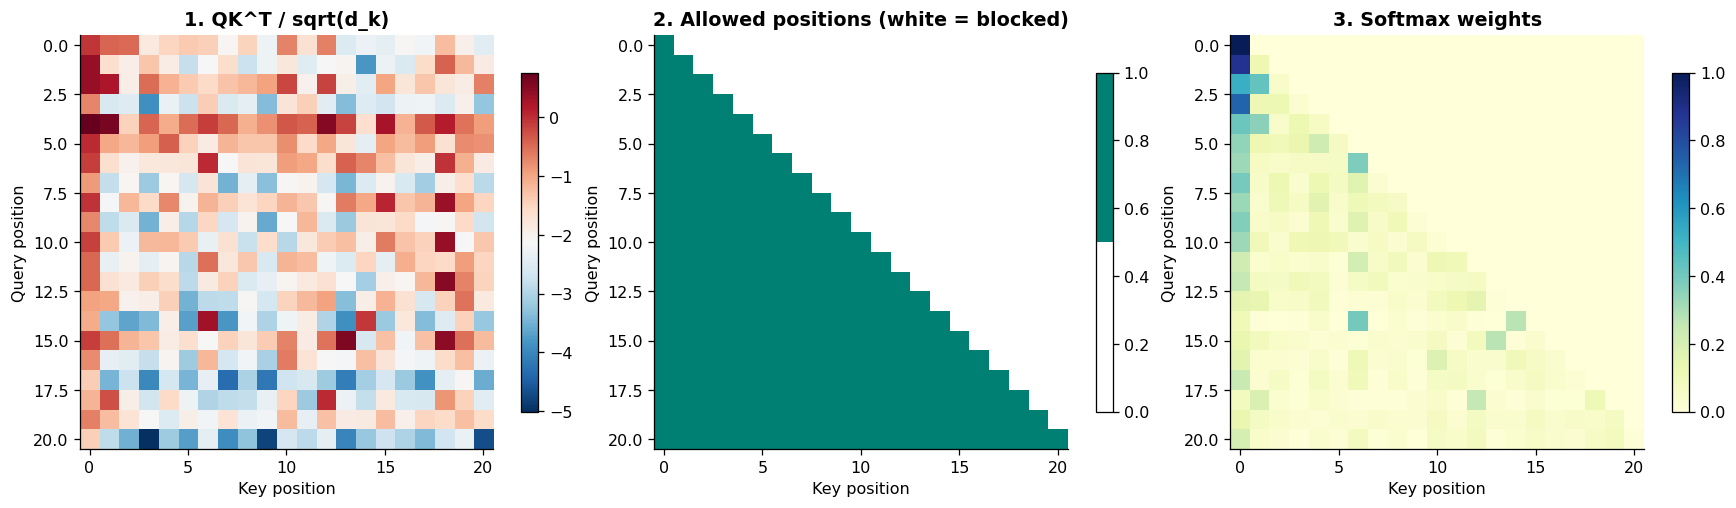

In [15]:
#@title 8.1 Scores → mask → softmax → weighted values
with torch.inference_mode():
    scores = Q @ K.transpose(-1, -2) / math.sqrt(HEAD_DIM)
    causal_allowed = torch.ones(T, T, dtype=torch.bool, device=DEVICE).tril()
    masked_scores = scores.masked_fill(~causal_allowed, -torch.inf)
    A = torch.softmax(masked_scores, dim=-1)
    head_outputs = A @ V
    attention_error = (A.cpu() - attentions[0]).abs().max().item()
    future_max = A.triu(diagonal=1).abs().max().item()
assert torch.allclose(A.sum(-1), torch.ones_like(A.sum(-1)), atol=1e-6)
assert future_max == 0.0
assert attention_error < 1e-4
print("Reconstructed vs model attention, max error:", attention_error)
print("Largest weight on a future token:", future_max)

head_index = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
panels = [scores[0, head_index].cpu().numpy(), causal_allowed.cpu().numpy(), A[0, head_index].cpu().numpy()]
for ax, data, title, cmap in zip(axes, panels,
                               ["1. QK^T / sqrt(d_k)", "2. Allowed positions (white = blocked)", "3. Softmax weights"],
                               ["RdBu_r", ListedColormap(["#FFFFFF", "#007F73"]), "YlGnBu"]):
    im = ax.imshow(data, aspect="equal", cmap=cmap)
    ax.set(title=title, xlabel="Key position", ylabel="Query position")
    fig.colorbar(im, ax=ax, shrink=.6)
finish(fig, "08_attention_steps")

**8.1 Follow one row through the panels.** A row is the query token receiving information; columns are key positions it may read. Q–K matching first produces scores. Dividing by √64 controls their scale; these are not probabilities yet.

The mask sets future scores to negative infinity. Softmax turns them into zero, leaving nonnegative weights whose row sum is 1. A value of 0.3 gives that position’s V a 30% mixing weight in this head; **it is not a 30% chance that the word is the answer**. `A @ V` then mixes the content into a vector.

Zeros above the diagonal mean “future access forbidden,” not “unimportant word.” Near-zero error confirms that our expanded calculation matches the model.

In [ ]:
#@title 8.2 Which values does one query mix?
QUERY_POSITION = -1 #@param {type:"integer"}
HEAD_INDEX = 0 #@param {type:"integer"}
if not -T <= QUERY_POSITION < T or not 0 <= HEAD_INDEX < HEADS:
    raise ValueError(f"query: {-T}〜{T-1}, head: 0〜{HEADS-1}")
qpos = QUERY_POSITION % T
row_weights = A[0, HEAD_INDEX, qpos].detach().cpu()
row_df = pd.DataFrame({
    "key position": range(T), "key token": [token_label(t) for t in ids],
    "allowed": [j <= qpos for j in range(T)], "attention weight": row_weights.numpy(),
})
print("Query:", labels[qpos], "| First layer, head:", HEAD_INDEX)
show_table(row_df.sort_values("attention weight", ascending=False).head(12), "08_query_weights.csv")
with torch.inference_mode():
    weighted_sum = (A[0, HEAD_INDEX, qpos, :, None] * V[0, HEAD_INDEX]).sum(dim=0)
assert torch.allclose(weighted_sum, head_outputs[0, HEAD_INDEX, qpos], atol=1e-5)
print("A weighted sum of", T, "Value vectors ->", HEAD_DIM, "coordinates")

**8.2 This table extracts one heatmap row.** `QUERY_POSITION` chooses who is reading: positions start at 0, and `-1` means the last token. `HEAD_INDEX` chooses which head to inspect: the default 12 heads are numbered 0–11. Zero is the first head, **not token zero or a layer number**. This cell uses the first layer.

Inspect the final period first, then select the `boot` position from 3.1 (15 by default). Rows are sorted by mixing weight. A partial top list need not sum to 1. Changing heads may change the ranking; that does not establish labels such as “subject head” or “Linux head.”

**Concrete example:** with the default sentence, `QUERY_POSITION=15` and `HEAD_INDEX=0` inspect the first layer’s first head at boot. Default GPT-2 gives Linux about 0.272, the largest weight in this row. Say “this head assigns Linux’s V about 27.2% mixing weight,” not “the whole model judges Linux most relevant.” Recheck the actual table after changing model, sentence, or head.

## 9. Multi-head: do not squeeze every relationship into one view

**Start with a problem: how do twelve heads hand their results to the next component?**

Each head has its own mixing pattern. Choosing one winner would discard the others. Concatenate twelve 64-coordinate outputs into 768 coordinates, then integrate them with an output projection.

**What we will check:** verify shapes and compare the same query across heads in 9.1; hold query fixed and vary head or layer in 9.2. Heads do not lengthen the sentence. Multi-head is not the sole source of parallelism: self-attention over known positions is itself parallelizable.

$$\operatorname{MHA}(Z)=\operatorname{Concat}(O_1,\ldots,O_h)W_O+b_O$$

Gather information through multiple learned projections, concatenate the results, and project back to the original width. **The sentence does not become longer when you add heads.**

Use the explorer below to switch layers and heads. Rows are receiving queries; columns are source keys.

Asking what a pronoun such as `it` refers to can motivate attention, but a heatmap alone does not establish successful coreference resolution. We keep our main sentence unchanged and observe the three Oracle occurrences instead of adding `it`.

In [ ]:
#@title 9.1 Concatenate heads and project back
with torch.inference_mode():
    concatenated = head_outputs.transpose(1, 2).contiguous().view(1, T, D)
    attention_update = block.attn.resid_dropout(block.attn.c_proj(concatenated))
print("Each head:", tuple(head_outputs.shape))
print("Concat:   ", tuple(concatenated.shape))
print("After Wo: ", tuple(attention_update.shape))

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for head, ax in enumerate(axes.flat):
    if head < HEADS:
        ax.imshow(attentions[0][0, head].numpy(), vmin=0, vmax=1, cmap="YlGnBu")
        ax.set(title=f"Layer 0 / Head {head}", xlabel="Key", ylabel="Query")
    else:
        ax.axis("off")
finish(fig, "09_multihead_grid")

**9.1 Each small plot is one head in the same layer.** Rows and columns have the same meaning as in 8.1. Pick one query row and compare where it reads across plots; you need not decode the entire grid. Heads can learn different mixing patterns, without assigned grammatical job titles.

Each of 12 heads contributes 64 coordinates. Concatenation restores 768, and an output projection mixes them. This is not a vote to pick a winning head. Heads and known sequence positions can be processed in parallel; multi-head alone is not what removes RNN-style sequential state updates. New tokens are still generated one at a time.

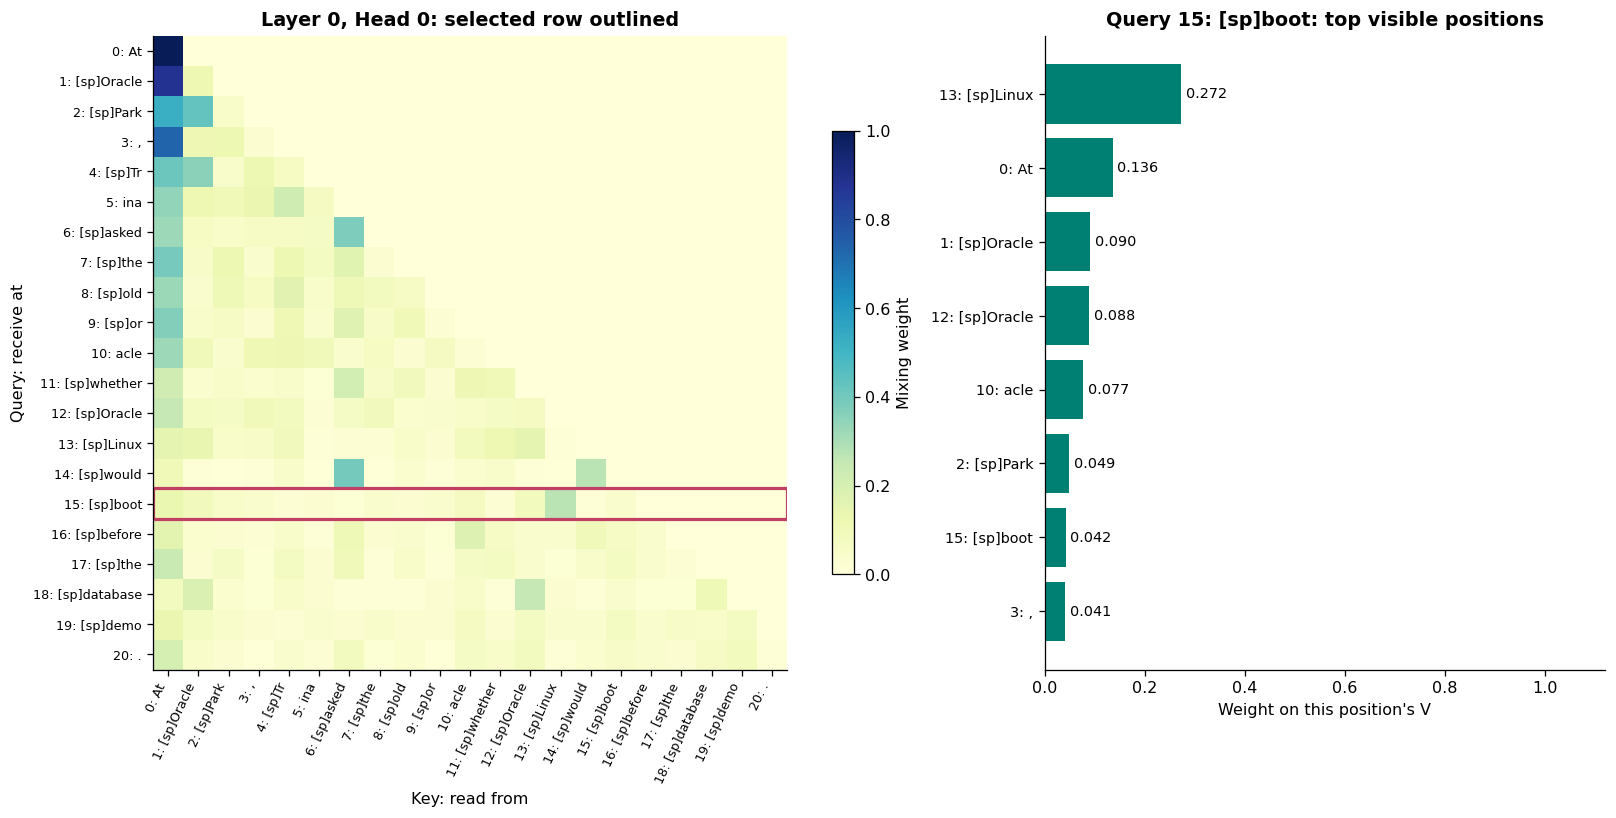

In [ ]:
#@title 9.2 Attention explorer
import ipywidgets as widgets

default_query = next((i for i, token_id in enumerate(ids) if tokenizer.decode([token_id]).strip() == "boot"), T-1)

def plot_attention(layer=0, head=0, query_position=None):
    query_position = default_query if query_position is None else int(query_position)
    if not (0 <= layer < LAYERS and 0 <= head < HEADS and 0 <= query_position < T):
        raise ValueError("Layer, head, or query position is out of range.")
    matrix = attentions[layer][0, head].numpy()
    fig, (ax, detail) = plt.subplots(1, 2, figsize=(15, max(7, T * .32)),
                                   gridspec_kw={"width_ratios": [1.6, 1]}, constrained_layout=True)
    im = ax.imshow(matrix, cmap="YlGnBu", vmin=0, vmax=1)
    ax.set_xticks(range(T), labels, rotation=65, ha="right", fontsize=8)
    ax.set_yticks(range(T), labels, fontsize=8)
    ax.add_patch(Rectangle((-.5, query_position-.5), T, 1, fill=False, edgecolor="#C13F65", linewidth=2))
    ax.set(title=f"Layer {layer}, Head {head}: selected row outlined", xlabel="Key: read from", ylabel="Query: receive at")
    fig.colorbar(im, ax=ax, shrink=.7, label="Mixing weight")
    row = matrix[query_position]
    ranked = np.argsort(-row[:query_position+1], kind="stable")[:8]
    bars = detail.barh(np.arange(len(ranked)), row[ranked], color="#007F73")
    detail.set_yticks(np.arange(len(ranked)), [labels[i] for i in ranked], fontsize=9)
    detail.invert_yaxis()
    detail.set(xlim=(0, 1.12), xlabel="Weight on this position's V", title=f"Query {labels[query_position]}: top visible positions")
    detail.bar_label(bars, labels=[f"{row[i]:.3f}" for i in ranked], padding=3, fontsize=9)
    finish(fig, "09_attention_selected")

# A static first view also works when widgets do not render.
plot_attention()
attention_widget = widgets.interactive(
    plot_attention,
    layer=widgets.IntSlider(min=0, max=LAYERS-1, step=1, value=0, description="Layer", continuous_update=False),
    head=widgets.IntSlider(min=0, max=HEADS-1, step=1, value=0, description="Head", continuous_update=False),
    query_position=widgets.IntSlider(min=0, max=T-1, step=1, value=default_query, description="Query", continuous_update=False),
)
display(attention_widget)


**9.2 Ask one small question: where does the boot row read?** The selected row is outlined; the right-hand bars show its highest weights among past and current positions. Longer bars mean more weight on that position’s V. Keep Query fixed, change Head, then Layer, instead of reading the whole matrix at once.

`Layer=0` is the first layer, `Head=0` its first head, and `Query` a sentence position. Query=0 can read only itself, so its weight must be 1: a useful first check. Then return to boot.

No head is required to point strongly at Linux. Some favor the previous token, themselves, or the beginning. These patterns show information mixing, not proof of causal reasoning, reference resolution, or word-sense understanding. The bars show only the top entries and need not sum to 1.

**What this shows:** How much weight a particular query assigns to each key in a particular layer and head.

**What it does not establish:** That a head is the stadium expert, that a line is the complete reasoning process, or that the largest weight is the most important cause. Values, output projections, residual paths, FFNs, and later layers also affect the result.

## 10. Do not skip the FFN

**Start with a problem: is mixing collected clues enough?**

Attention gathers weighted content. We also need more complex combinations of the resulting features. The FFN expands features, applies a nonlinearity, then projects back. Stacked linear layers alone collapse to one linear transform; nonlinearity goes beyond that limit.

**What we will check:** 768→3072→768 shapes, GELU’s numerical effect, and position-wise processing. This is not a separate Oracle sense classifier.

Attention mixes information **between tokens**. The FFN / MLP applies a nonlinear transformation **across features within each position**. It shares the same weights across positions and does not directly read other positions.

Using row vectors:
$$\operatorname{FFN}(z)=\operatorname{GELU}(zW_1+b_1)W_2+b_2$$

For GPT-2 small, the width is $768\rightarrow3072\rightarrow768$: expand, apply nonlinearity, then return to a width that can be added to the residual stream. The original paper uses ReLU; GPT-2 uses a GELU variant.

There is no dedicated FFN that classifies `Oracle` into company, stadium, or prophet. Context-dependent features emerge through attention, FFNs, and residual paths across layers. In causal GPT-2, the `Oracle` position also cannot yet read the `Park` or `Linux` to its right.

Whole first block vs model, max absolute error: 0.0
Change token 0 at MLP input -> max change at other positions: 0.0


stage,shape
after attention residual,"(1, 21, 768)"
LN2,"(1, 21, 768)"
first affine (expand),"(1, 21, 3072)"
GELU,"(1, 21, 3072)"
second affine (project back),"(1, 21, 768)"
second residual add,"(1, 21, 768)"


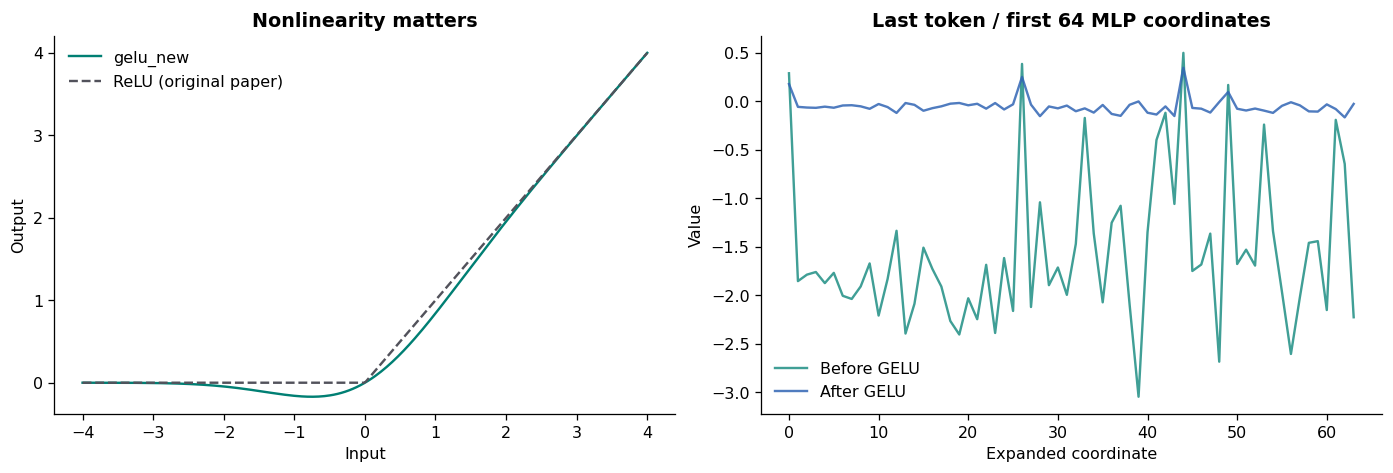

In [19]:
#@title 10.1 Expand, apply a nonlinearity, and project back
with torch.inference_mode():
    after_attention = h0 + attention_update
    mlp_input = block.ln_2(after_attention)
    expanded = block.mlp.c_fc(mlp_input)
    activated = block.mlp.act(expanded)
    mlp_update = block.mlp.dropout(block.mlp.c_proj(activated))
    reconstructed_block = after_attention + mlp_update
    block_error = (reconstructed_block.cpu() - hidden_states[1]).abs().max().item()
assert block_error < 2e-4
show_table(pd.DataFrame([
    {"stage": "after attention residual", "shape": str(tuple(after_attention.shape))},
    {"stage": "LN2", "shape": str(tuple(mlp_input.shape))},
    {"stage": "first affine (expand)", "shape": str(tuple(expanded.shape))},
    {"stage": "GELU", "shape": str(tuple(activated.shape))},
    {"stage": "second affine (project back)", "shape": str(tuple(mlp_update.shape))},
    {"stage": "second residual add", "shape": str(tuple(reconstructed_block.shape))},
]))
print("Whole first block vs model, max absolute error:", block_error)

with torch.inference_mode():
    gx = torch.linspace(-4, 4, 300, device=DEVICE)
    gy = block.mlp.act(gx)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(gx.cpu(), gy.cpu(), label=cfg.activation_function)
axes[0].plot(gx.cpu(), gx.relu().cpu(), "--", color=COLORS[3], label="ReLU (original paper)")
axes[0].set(title="Nonlinearity matters", xlabel="Input", ylabel="Output"); axes[0].legend(frameon=False)
axes[1].plot(expanded[0, -1, :64].cpu(), label="Before GELU", alpha=.75)
axes[1].plot(activated[0, -1, :64].cpu(), label="After GELU", alpha=.85)
axes[1].set(title="Last token / first 64 MLP coordinates", xlabel="Expanded coordinate", ylabel="Value")
axes[1].legend(frameon=False)
finish(fig, "10_ffn")

# Change one position; a position-wise MLP cannot directly change other positions.
with torch.inference_mode():
    perturbed = mlp_input.clone()
    perturbed[:, 0, 0] += 1
    mlp_position_error = (block.mlp(perturbed)[:, 1:] - block.mlp(mlp_input)[:, 1:]).abs().max().item()
assert mlp_position_error < 1e-6
print("Change token 0 at MLP input -> max change at other positions:", mlp_position_error)

**10.1 Attention brings information from other positions; the FFN transforms features at each position.** The default path is 768 → 3072 → 768: expand, apply nonlinear GELU, and project back. Stacking only linear operations could be collapsed into one linear transform; nonlinearity enables more complex feature combinations.

The GELU plot shows input values on x and output values on y, not token positions or class probabilities. Negative inputs are generally suppressed, not all set exactly to zero. The separate perturbation check changes one position: other positions’ FFN outputs stay unchanged because the FFN does not directly mix tokens.

The FFN matters, but Oracle’s sense cannot be attributed to it alone. It processes contextual information supplied by attention across many layers. This cell does not classify Oracle as company, prophet, or stadium.

The other plot fixes the last token and shows its first 64 expanded coordinates. The two lines compare values before and after GELU. A changed height at the same coordinate is a nonlinear numerical transformation, not selection of a different word.

## 11. Add & Norm: a structure that supports depth

**Start with a problem: how can information and learning signals survive many processing layers?**

If each layer must replace the old state, information and backward gradients traverse every transformation. A residual adds an update to the old state, providing a direct path. LayerNorm addresses a different issue: changing feature scales, using normalization followed by learned scale and bias.

**Separate two kinds of evidence:** the first plot measures GPT-2 vector sizes; the second scalar toy measures derivatives across depth. The first is not a gradient plot, and small loss is not the same as a small gradient.

A GPT-2 block follows this order. Dropout is an identity operation in `eval()` mode.

$$u=x+\operatorname{MHA}(\operatorname{LN}_1(x)),\qquad
y=u+\operatorname{MLP}(\operatorname{LN}_2(u))$$

A residual connection adds an update to the existing representation. For $y=x+F(x)$, the local Jacobian is $I+\partial F/\partial x$. This provides an identity path, not an unconditional guarantee of healthy gradients or successful training.

LayerNorm normalizes over **the feature dimensions of each token**, then applies learned scale and bias:
$$\operatorname{LN}(x)=\gamma\odot\frac{x-\mu(x)}{\sqrt{\sigma^2(x)+\epsilon}}+\beta$$

Because $\gamma,\beta$ are learned, the output does not necessarily have mean 0 and standard deviation 1. LayerNorm is not a device for making loss larger.

The original paper's **post-norm** order is $\mathrm{LN}(x+F(x))$. Keep that distinct from GPT-2's pre-norm order so the equations match the code. [GPT-2 report §2.3](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)

stage,last-token mean,last-token std,last-token L2 norm
h0,0.00079,0.17046,4.72396
LN1(h0),-0.00800,0.08652,2.40799
attention update,0.02202,1.17596,32.59473
after attention add,0.02281,1.19336,33.07740
LN2,-0.00292,0.14673,4.06722
MLP update,-0.00194,0.94398,26.16039
block output,0.02087,1.92136,53.24941


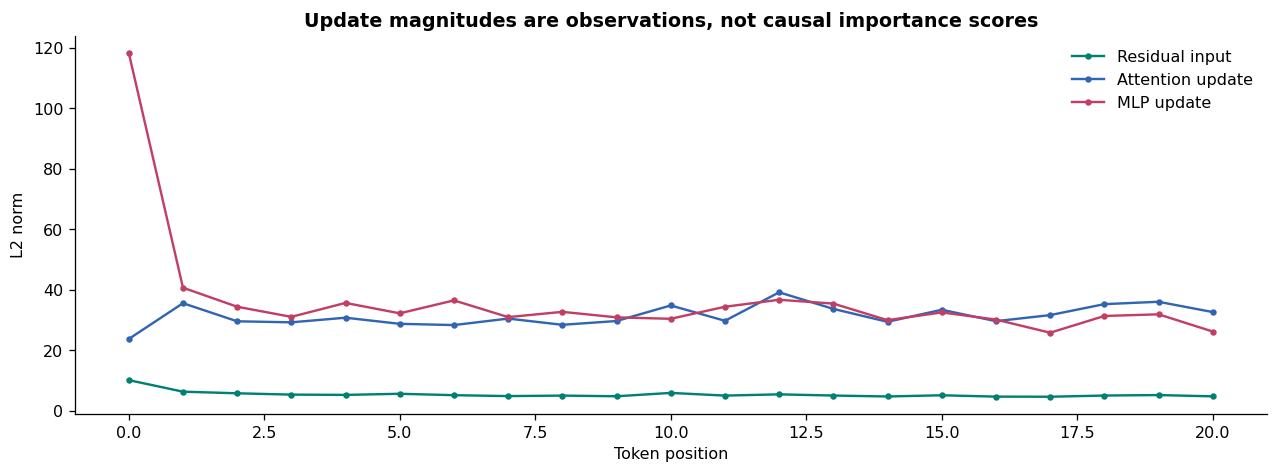

depth,plain,residual
1,1.000e-01,9.000e-01
2,1.000e-02,8.100e-01
5,1.000e-05,5.905e-01
10,1.000e-10,3.487e-01
20,1.000e-20,1.216e-01
40,1.000e-40,1.478e-02


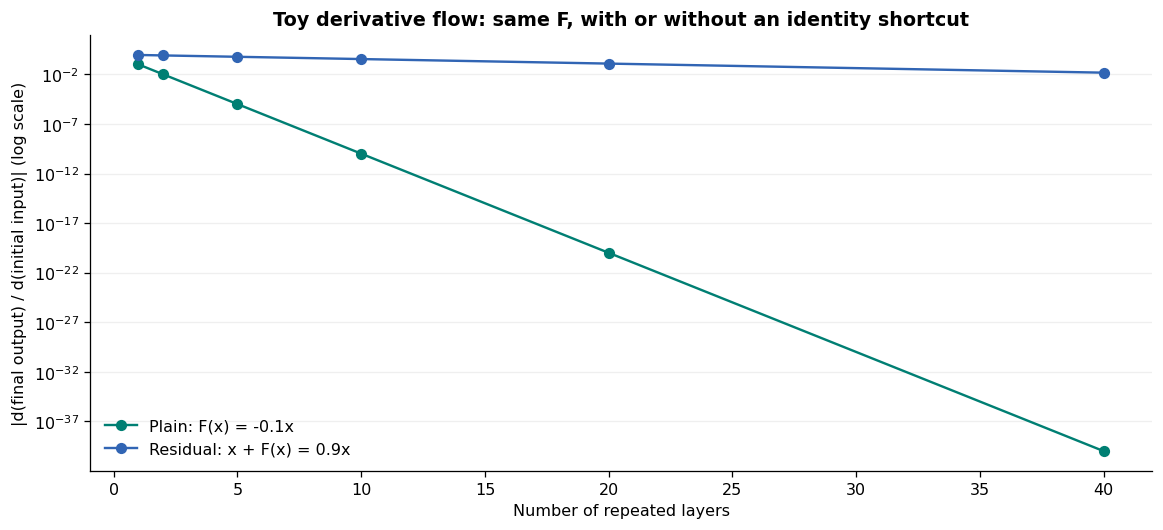

In [ ]:
#@title 11.1 Measured residual updates and LayerNorm statistics
stages = {"h0": h0, "LN1(h0)": z, "attention update": attention_update,
          "after attention add": after_attention, "LN2": mlp_input,
          "MLP update": mlp_update, "block output": reconstructed_block}
show_table(pd.DataFrame([
    {"stage": name, "last-token mean": tensor[0, -1].mean().item(),
     "last-token std": tensor[0, -1].std(unbiased=False).item(),
     "last-token L2 norm": tensor[0, -1].norm().item()}
    for name, tensor in stages.items()
]), "11_residual_norm.csv")
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
for name, tensor in [("Residual input", h0), ("Attention update", attention_update), ("MLP update", mlp_update)]:
    ax.plot(tensor[0].norm(dim=-1).cpu(), marker=".", label=name)
ax.set(title="Update magnitudes are observations, not causal importance scores", xlabel="Token position", ylabel="L2 norm")
ax.legend(frameon=False)
finish(fig, "11_residual_magnitudes")

# Scalar autograd demonstration, NOT gradients from GPT-2 training.
# Both paths use the same F(x)=-0.1*x; only the identity shortcut differs.
gradient_rows = []
for depth in [1, 2, 5, 10, 20, 40]:
    measured = {}
    for residual in [False, True]:
        initial = torch.tensor(1.0, dtype=torch.float64, requires_grad=True)
        value = initial
        for _ in range(depth):
            update = -0.1 * value
            value = value + update if residual else update
        derivative = torch.autograd.grad(value, initial)[0].abs().item()
        expected = (0.9 if residual else 0.1) ** depth
        assert math.isclose(derivative, expected, rel_tol=1e-12)
        measured["residual" if residual else "plain"] = derivative
    gradient_rows.append({"depth": depth, **measured})
gradient_df = pd.DataFrame(gradient_rows)
display(gradient_df.style.hide(axis="index").format({"plain": "{:.3e}", "residual": "{:.3e}"}))
gradient_df.to_csv(ARTIFACTS / "11_gradient_toy.csv", index=False)
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for column, label in [("plain", "Plain: F(x) = -0.1x"), ("residual", "Residual: x + F(x) = 0.9x")]:
    ax.semilogy(gradient_df["depth"], gradient_df[column], marker="o", label=label)
ax.set(title="Toy derivative flow: same F, with or without an identity shortcut",
       xlabel="Number of repeated layers", ylabel="|d(final output) / d(initial input)| (log scale)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=.2)
finish(fig, "11_gradient_flow_toy")


**11.1 Separate vector size from gradient flow.** The first table and line plot measure vector means, standard deviations, and lengths (L2 norms). A higher line means a longer vector, not greater importance. It cannot diagnose vanishing gradients.

The new second plot demonstrates gradient flow. Loss scores prediction error. A gradient describes the local direction and rate at which a quantity changes when an input or parameter changes. Backpropagation multiplies derivatives through layers; many factors smaller than 1 can leave earlier layers with very small signals and slow updates.

Our scalar toy uses `F(x)=-0.1x`. Stacking F multiplies gradient magnitude by 0.1 per layer. Adding a residual gives `x+F(x)=0.9x`, multiplying by 0.9 instead. The x-axis is depth; the logarithmic y-axis shows how small the signal becomes. Values are computed with autograd. They are derivatives of final output with respect to initial input, **not measured GPT-2 training-loss gradients**.

The key is `d(x+F(x))/dx = 1+F′(x)`: the shortcut adds a direct path. Residuals do not guarantee that gradients never vanish or explode. LayerNorm adjusts feature scales; it serves a different purpose and does not increase the loss. GPT-2 uses pre-norm, unlike the original paper’s post-norm layout.

LayerNorm includes learned scale and bias, so its displayed output mean and standard deviation need not be exactly 0 and 1.

## 12. Now look at that familiar Transformer figure

**Start with a problem:** How do the parts form a model? Trace the calculations you ran along GPT-2’s path, then compare the original encoder–decoder and its source-reference path.

**Next:** read the design, run the small experiment, then use the reading guide below its output.

![Original Transformer architecture, Figure 1](https://arxiv.org/html/1706.03762v7/Figures/ModalNet-21.png)

*Source: Vaswani et al., [Attention Is All You Need, Figure 1](https://arxiv.org/html/1706.03762v7#S3). This is the original figure. If the external image does not load, the diagram generated below still shows the structure.*

| | Original Transformer | GPT-2 in this notebook |
| :--- | :--- | :--- |
| Overall architecture | Encoder + decoder | Decoder-only |
| Attention | Encoder self / masked decoder self / cross | Causal self-attention |
| Position | Sinusoidal PE | Learned absolute embeddings |
| Normalization | Post-norm | Pre-norm + final LN |
| FFN | ReLU | GELU variant |
| Generation | Encode the source, generate the target | Continue the prompt |

GPT-2 is not simply the original decoder cut out of the diagram. Its standard configuration has no cross-attention to encoder outputs.

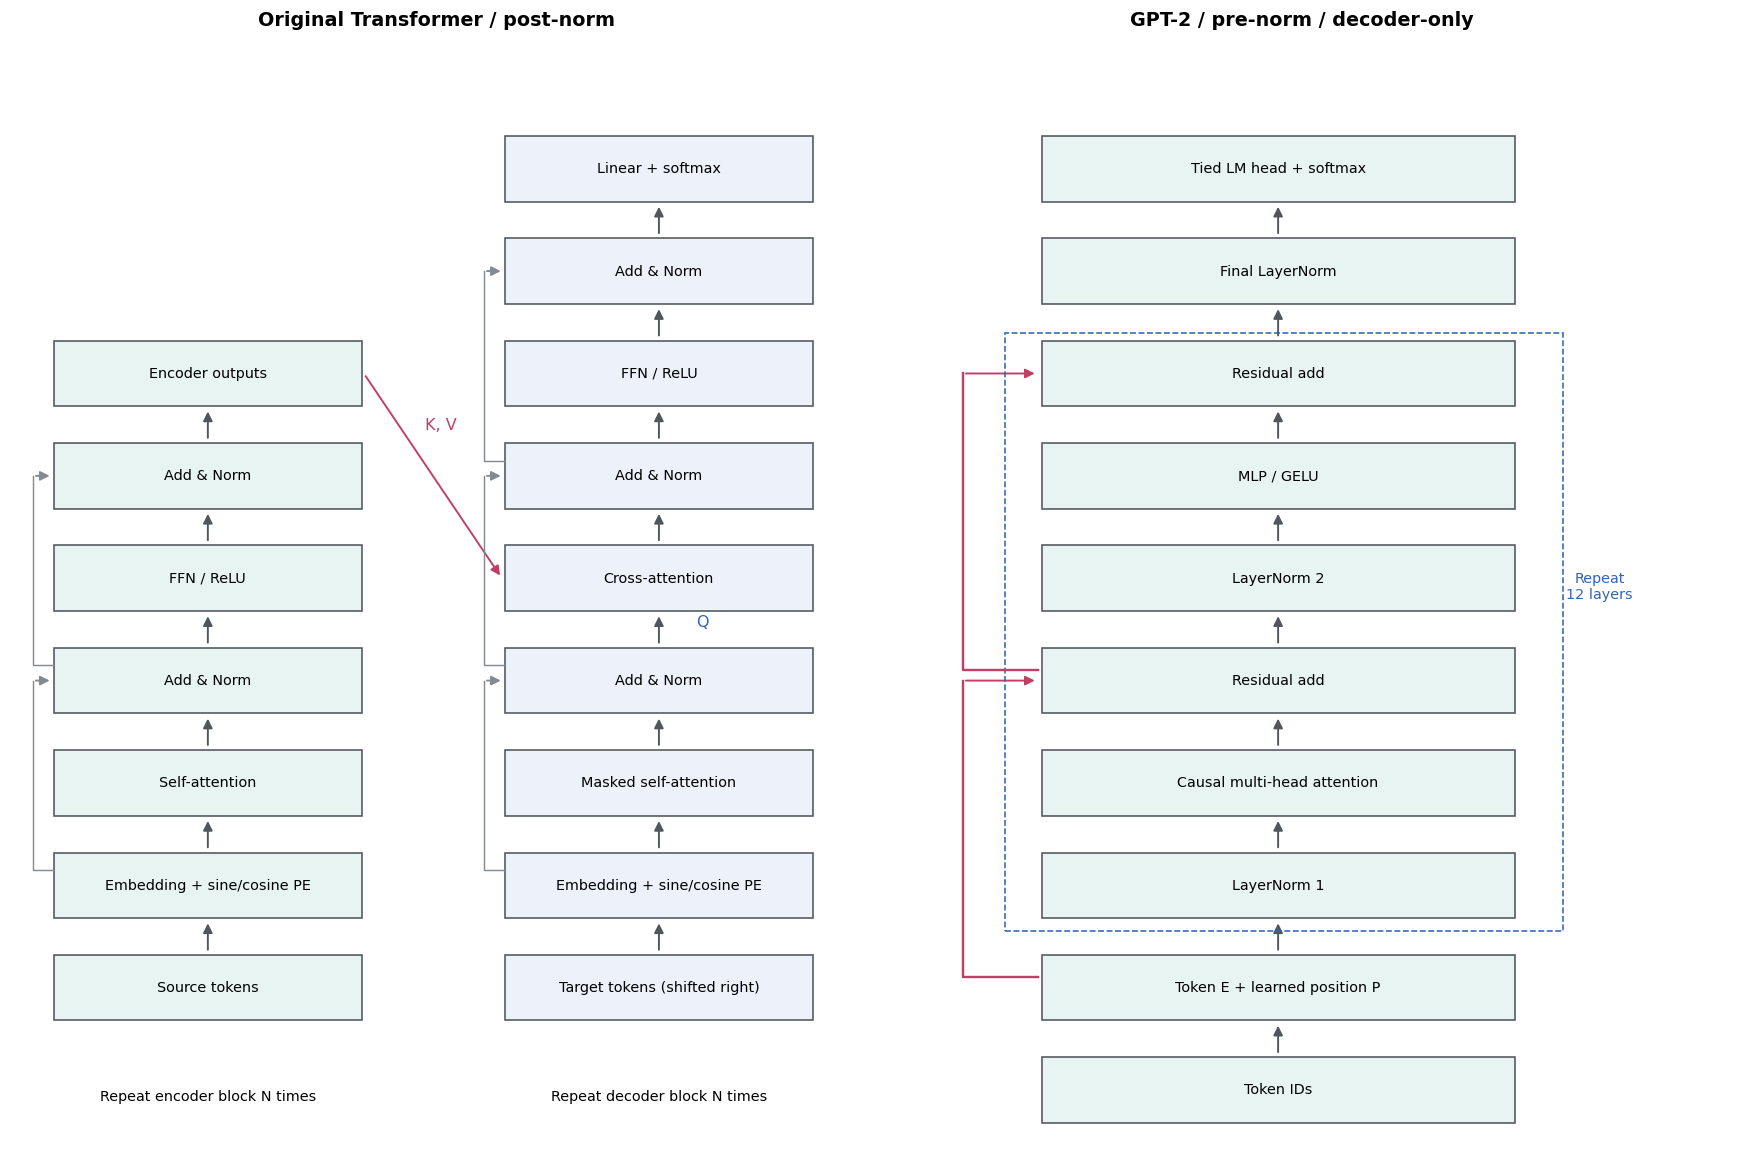

In [21]:
#@title 12.1 Draw the original Transformer and GPT-2 paths
def box(ax, x, y, text, color="#E8F4F1", width=2.9, height=.64):
    ax.add_patch(Rectangle((x-width/2, y-height/2), width, height, facecolor=color, edgecolor="#50565D", linewidth=1))
    ax.text(x, y, text, ha="center", va="center", fontsize=9)

def arrow(ax, start, end, color="#50565D", style="-", connection="arc3,rad=0"):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=12,
                                linewidth=1.2, color=color, linestyle=style, connectionstyle=connection))

fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
ax = axes[0]
ax.set(xlim=(0, 8), ylim=(-.6, 10.3), title="Original Transformer / post-norm")
ax.axis("off")
encoder_nodes = [(1, "Source tokens"), (2, "Embedding + sine/cosine PE"),
                 (3, "Self-attention"), (4, "Add & Norm"), (5, "FFN / ReLU"),
                 (6, "Add & Norm"), (7, "Encoder outputs")]
decoder_nodes = [(1, "Target tokens (shifted right)"), (2, "Embedding + sine/cosine PE"),
                 (3, "Masked self-attention"), (4, "Add & Norm"), (5, "Cross-attention"),
                 (6, "Add & Norm"), (7, "FFN / ReLU"), (8, "Add & Norm"), (9, "Linear + softmax")]
for x, nodes in [(1.85, encoder_nodes), (6.1, decoder_nodes)]:
    for y, label in nodes:
        box(ax, x, y, label, "#E8F4F1" if x < 4 else "#EDF2FA")
    for (y1, _), (y2, _) in zip(nodes, nodes[1:]):
        arrow(ax, (x, y1+.34), (x, y2-.34))
arrow(ax, (3.32, 7), (4.62, 5), color=COLORS[2])
ax.text(4.05, 6.45, "K, V", ha="center", color=COLORS[2], fontsize=10)
ax.text(6.45, 4.53, "Q", color=COLORS[1], fontsize=10)
for x, pairs in [(1.85, [(2, 4), (4, 6)]), (6.1, [(2, 4), (4, 6), (6, 8)])]:
    for a, b in pairs:
        bypass = x - 1.65
        ax.plot([x-1.46, bypass, bypass], [a+.15, a+.15, b], color="#838A91", lw=.9)
        arrow(ax, (bypass, b), (x-1.46, b), color="#838A91")
ax.text(1.85, -.1, "Repeat encoder block N times", ha="center", fontsize=9)
ax.text(6.1, -.1, "Repeat decoder block N times", ha="center", fontsize=9)

ax = axes[1]
ax.set(xlim=(0, 7), ylim=(-.6, 10.3), title="GPT-2 / pre-norm / decoder-only")
ax.axis("off")
nodes = [(0, "Token IDs"), (1, "Token E + learned position P"), (2, "LayerNorm 1"),
         (3, "Causal multi-head attention"), (4, "Residual add"), (5, "LayerNorm 2"),
         (6, "MLP / GELU"), (7, "Residual add"), (8, "Final LayerNorm"), (9, "Tied LM head + softmax")]
for y, label in nodes:
    box(ax, 3.3, y, label, width=3.9)
for (a, _), (b, _) in zip(nodes, nodes[1:]):
    arrow(ax, (3.3, a+.34), (3.3, b-.34))
for a, b in [(1, 4), (4, 7)]:
    ax.plot([1.32, .7, .7], [a+.1, a+.1, b], color=COLORS[2])
    arrow(ax, (.7, b), (1.32, b), color=COLORS[2])
ax.add_patch(Rectangle((1.05, 1.55), 4.6, 5.85, fill=False, edgecolor=COLORS[1], linestyle="--"))
ax.text(5.95, 4.8, f"Repeat\n{LAYERS} layers", ha="center", fontsize=9, color=COLORS[1])
finish(fig, "12_architecture_comparison")

**12.1 Follow the arrows and recognize the parts you have run.** In the original Transformer, the encoder reads the source. The decoder reads its written prefix and uses cross-attention to consult encoder states. GPT-2 uses a decoder-style causal self-attention path, without a separate encoder or cross-attention.

Repeated blocks refine representations; they do not each write one word. GPT-2 finishes with LayerNorm and an LM head, then softmax turns next-token scores into a distribution. This is an architecture guide; we have not trained or run the original translation model.

## 13. The same token can have different contextual states

**Start with a problem:** The same ID starts with the same vector. Does it stay the same after different prefixes? Compare processed states, then change only future text to test the mask. Context effects do not automatically prove sense classification.

**Next:** read the design, run the small experiment, then use the reading guide below its output.

An input embedding is fixed for a given ID. A contextual hidden state depends on position and accessible context.

The Oracle occurrences differ in position as well as context; lowercase `oracle` can also have different token IDs. For a word split into multiple tokens, we inspect **its final subtoken position**, not an average over the word.

Separate two observations:
1. Compare the three occurrences across layers. **This is not a word-sense classification accuracy test.**
2. Change only the suffix after a shared prefix and confirm that future tokens do not change past states.

In Hugging Face, `hidden_states[0]` is embedding + position. Intermediate entries are inputs to the following blocks. **The last entry includes the final LayerNorm**, so the last transition includes that normalization too.

In [ ]:
#@title 13.1 Inspect Oracle / oracle states across layers
oracle_matches = list(re.finditer(r"\boracle\b", TEXT, flags=re.IGNORECASE))
oracle_positions = []
for match in oracle_matches:
    span_tokens = [i for i, (a, b) in enumerate(offsets) if a < match.end() and b > match.start()]
    if span_tokens:
        # The final subtoken has read the complete surface form under a causal mask.
        oracle_positions.append((span_tokens[-1], f"{match.group()} @{match.start()}"))

layer_names = ["Input E+P"] + [f"Block {i}" for i in range(1, LAYERS)] + [f"Block {LAYERS} + final LN"]
shape_df = pd.DataFrame({"state": layer_names, "shape": [str(tuple(h.shape)) for h in hidden_states]})
show_table(shape_df, "13_hidden_shapes.csv")
context_rows = []
if len(oracle_positions) >= 2:
    for a, b in combinations(range(len(oracle_positions)), 2):
        posa, namea = oracle_positions[a]
        posb, nameb = oracle_positions[b]
        name = f"{namea} vs {nameb}"
        context_rows.append({"pair": name, "state": "Input E only", "step": -1,
                             "cosine": F.cosine_similarity(E[ids[posa]], E[ids[posb]], dim=0).item()})
        for step, h in enumerate(hidden_states):
            context_rows.append({"pair": name, "state": layer_names[step], "step": step,
                                 "cosine": F.cosine_similarity(h[0, posa], h[0, posb], dim=0).item()})
    context_df = pd.DataFrame(context_rows)
    fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
    for name, subset in context_df.groupby("pair", sort=False):
        ax.plot(subset.step, subset.cosine, marker="o", ms=4, label=name)
    ax.set(title="Oracle occurrences / observed cosine, not a meaning classifier",
           xlabel="-1: E only; 0: E+P; 1...: blocks (last includes final LN)", ylabel="Cosine similarity")
    ax.legend(frameon=False, fontsize=8)
    finish(fig, "13_oracle_hidden_states")
    context_df.to_csv(ARTIFACTS / "13_oracle_hidden_states.csv", index=False)
    print("Measured positions:", [(pos, name, labels[pos]) for pos, name in oracle_positions])
else:
    print("This edited text contains fewer than two Oracle occurrences; comparison skipped.")

**13.1 Each line compares vectors at two Oracle occurrences.** The x-axis follows processing depth; y is cosine similarity. Higher means similar directions, not classification accuracy. Changing curves show changing representations; they need not decrease steadily.

When lowercase oracle splits, we select its final piece, introducing subword, case, and position differences. Crucially, an Oracle position cannot read the following Park or Linux. This plot cannot show that it classified itself using that future word.

In [ ]:
#@title 13.2 Change the future; shared-prefix states stay the same
common_prefix = "At Oracle Park, Trina asked the old oracle whether Oracle"
suffix_a = " Linux would boot before the database demo."
suffix_b = " announced a concert at the stadium."
prefix_ids = tokenizer.encode(common_prefix, add_special_tokens=False)
ids_a = tokenizer.encode(common_prefix + suffix_a, add_special_tokens=False)
ids_b = tokenizer.encode(common_prefix + suffix_b, add_special_tokens=False)
assert ids_a[:len(prefix_ids)] == ids_b[:len(prefix_ids)] == prefix_ids
with torch.inference_mode():
    out_a = model(torch.tensor([ids_a], device=DEVICE), output_hidden_states=True, use_cache=False)
    out_b = model(torch.tensor([ids_b], device=DEVICE), output_hidden_states=True, use_cache=False)
prefix_errors = [
    (a[:, :len(prefix_ids)] - b[:, :len(prefix_ids)]).abs().max().item()
    for a, b in zip(out_a.hidden_states, out_b.hidden_states)
]
causal_error = max(prefix_errors)
print("A:", common_prefix + suffix_a)
print("B:", common_prefix + suffix_b)
print("Max error at every shared-prefix position, across all states:", causal_error)
assert causal_error < 3e-4
print("The Oracle before the suffix cannot read Linux or announced yet.")
del out_a, out_b

**13.2 “Almost unchanged” is the intended result.** The sentences share a prefix and differ only afterward. Near-zero differences in shared-prefix states demonstrate that the causal mask blocks future access. GPU arithmetic may leave tiny numerical differences.

At the later Linux position, the model can use the preceding Oracle. It cannot retroactively revise the earlier Oracle state using that suffix.

**The important consequence:** GPT-2 can use the complete phrase `Oracle Linux` at the `Linux` position and later. Words to the right do not retroactively update the hidden state of the earlier `Oracle`.

A bidirectional encoder such as BERT can use both sides. Do not transfer that explanation unchanged to GPT-2.

Same token ID: 6297 [sp]boot
Context, position, and syntax all differ. This is not an isolated FFN experiment or a clustering guarantee.


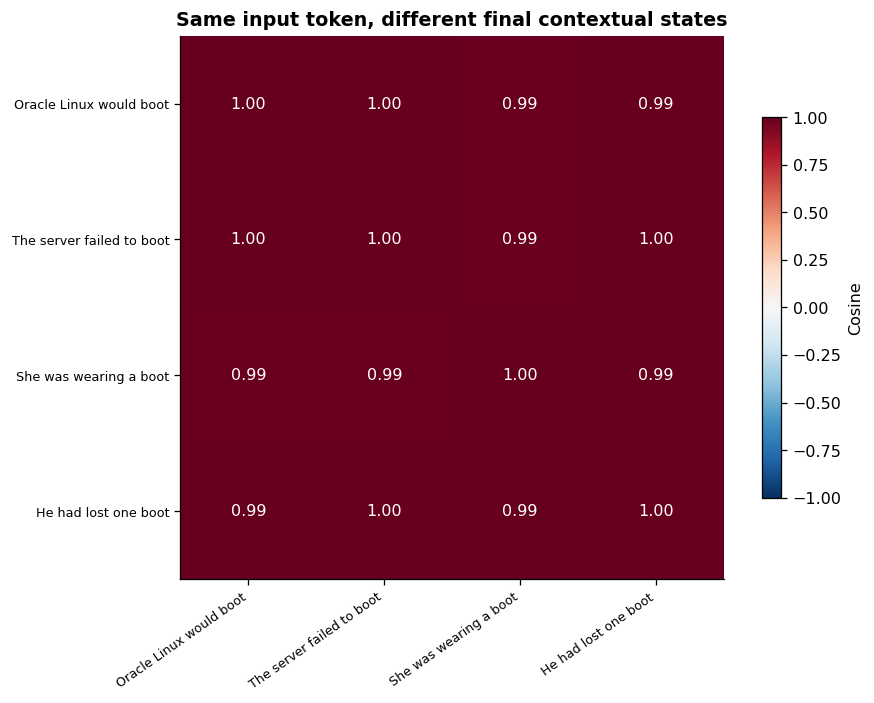

sentence A,sentence B,human sense grouping,cosine
Oracle Linux would boot,The server failed to boot,same sense,0.99759
Oracle Linux would boot,She was wearing a boot,different senses,0.98619
Oracle Linux would boot,He had lost one boot,different senses,0.99377
The server failed to boot,She was wearing a boot,different senses,0.99022
The server failed to boot,He had lost one boot,different senses,0.99543
She was wearing a boot,He had lost one boot,same sense,0.99309


In [ ]:
#@title 13.3 An exploratory sense experiment: boot with the same token ID
boot_sentences = [
    "Oracle Linux would boot",
    "The server failed to boot",
    "She was wearing a boot",
    "He had lost one boot",
]
boot_representations, boot_token_ids = [], []
with torch.inference_mode():
    for sentence in boot_sentences:
        batch = tokenizer(sentence, return_tensors="pt").to(DEVICE)
        result = model(**batch, output_hidden_states=True, use_cache=False)
        boot_token_ids.append(batch.input_ids[0, -1].item())
        boot_representations.append(result.hidden_states[-1][0, -1].cpu())
assert len(set(boot_token_ids)) == 1
boot_vectors = F.normalize(torch.stack(boot_representations), dim=-1)
boot_cosines = boot_vectors @ boot_vectors.T
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
im = ax.imshow(boot_cosines, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(4), boot_sentences, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(4), boot_sentences, fontsize=8)
ax.set(title="Same input token, different final contextual states")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{boot_cosines[i,j]:.2f}", ha="center", va="center", color="white" if abs(boot_cosines[i,j]) > .65 else "black")
fig.colorbar(im, ax=ax, shrink=.7, label="Cosine")
finish(fig, "13_boot_context")
print("Same token ID:", boot_token_ids[0], token_label(boot_token_ids[0]))
print("Context, position, and syntax all differ. This is not an isolated FFN experiment or a clustering guarantee.")

# Exclude self-comparisons; show every pair rather than promise clustering.
boot_pair_rows = []
for i, j in combinations(range(4), 2):
    boot_pair_rows.append({
        "sentence A": boot_sentences[i], "sentence B": boot_sentences[j],
        "human sense grouping": "same sense" if (i < 2) == (j < 2) else "different senses",
        "cosine": boot_cosines[i, j].item(),
    })
show_table(pd.DataFrame(boot_pair_rows), "13_boot_pairs.csv")


**13.3 A clean two-cluster picture is not required for a useful result.** Each row/column is the final ` boot` state from one sentence. Cells compare two states by cosine. Ignore the diagonal: self-comparison is always 1. Use the pair table below to check whether within-sense similarities really exceed cross-sense ones.

The final token ID is identical in all four sentences, so its initial token embedding is identical. Different prefixes and positions can produce different final vectors. That is the directly demonstrated result. **Cosine is not the probability that boot means footwear.** Shared spelling, syntax, and representation geometry can also produce high similarities.

If startup and footwear do not separate clearly, report that this checkpoint, final layer, metric, and four examples do not yield clean clusters. Do not manufacture success through color scaling, or conclude that the model understands nothing. Testing sense discrimination requires more controlled examples and independent evaluation.

## 14. Logits → softmax → the next token

**Start with a problem:** The model still has vectors; how does it return to text? An LM head scores vocabulary candidates, and softmax forms a distribution. Check the calculation, then inspect actual candidates after would.

**Next:** read the design, run the small experiment, then use the reading guide below its output.

GPT-2 projects final hidden states to vocabulary scores. Its input embedding and LM head share weights.

$$\text{logits}_t=h_t^{\mathrm{final}} E^\top,\qquad
p(x_{t+1}\mid x_{\le t})=\operatorname{softmax}(\text{logits}_t)$$

Our prediction prompt ends at `would`. **We have not supplied `boot before the database demo`.** Do not attribute a prediction to context that the model has not received.

The top-k table shows only part of the full-vocabulary distribution, so its probabilities generally sum to less than 1. `boot` does not need to rank first. Read the measured distribution rather than the answer we hoped for.

In [ ]:
#@title 14.1 Verify tied LM-head weights and logits
with torch.inference_mode():
    manual_logits = outputs.hidden_states[-1] @ model.transformer.wte.weight.T
    logits_error = (manual_logits - outputs.logits).abs().max().item()
weights_tied = model.lm_head.weight.data_ptr() == model.transformer.wte.weight.data_ptr()
assert weights_tied
assert logits_error < 3e-4
print("Input embedding and LM head share storage:", weights_tied)
print("Manual logits reconstruction max error:", logits_error)

**14.1 Convert each 768-coordinate state into scores for all candidate tokens.** The LM head is the final vocabulary output layer, not an attention head. At each position, logits contain 50,257 unnormalized scores, not probabilities.

`weights tied=True` means GPT-2 shares input lookup and output projection weights. It does not simply reverse the lookup to recover the input word. The processed state contains available context and predicts the next token. Small reconstruction error verifies this calculation.

Probability mass displayed: 0.5891499537974596


<IPython.core.display.Markdown object>

rank,token,ID,logit,probability
1,[sp]be,307,-120.73940,0.27318
2,[sp]ever,1683,-121.90615,0.08506
3,[sp]allow,1249,-122.55940,0.04426
4,[sp]support,1104,-122.85310,0.03300
5,[sp]have,423,-122.86459,0.03262
6,[sp]continue,2555,-122.90955,0.03119
7,[sp]work,670,-123.22068,0.02285
8,[sp]make,787,-123.37057,0.01967
9,[sp]accept,2453,-123.61191,0.01545
10,[sp]still,991,-123.81736,0.01258


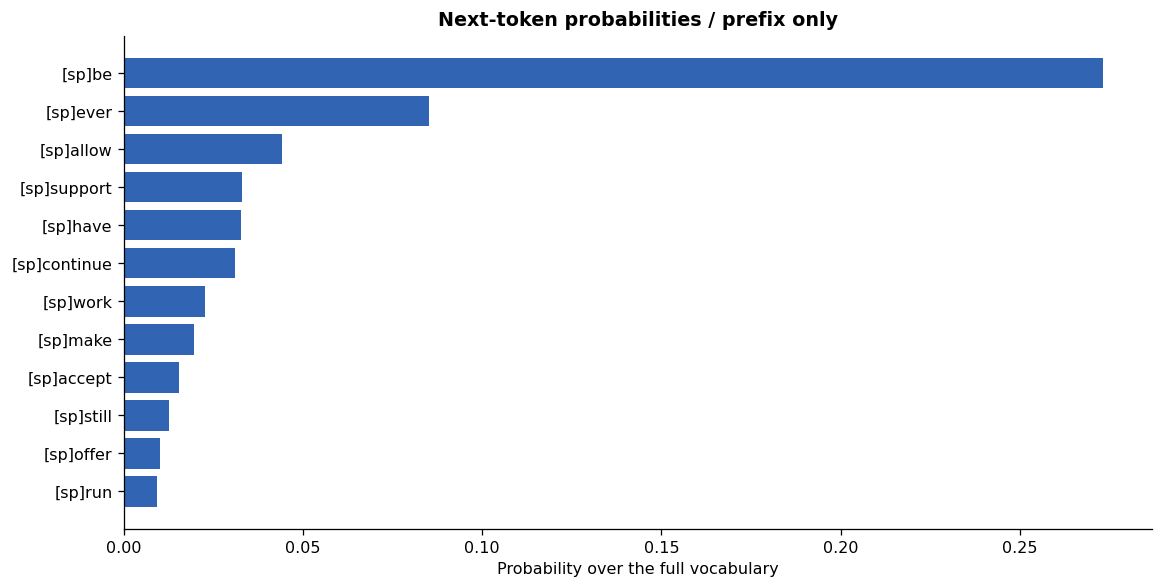

candidate,probability,rank
' boot',0.00052,167
' run',0.00920,12
' start',0.00276,47
' work',0.02285,7
' survive',0.00499,27


In [26]:
#@title 14.2 Predict what follows would
PROMPT = "At Oracle Park, Trina asked the old oracle whether Oracle Linux would" #@param {type:"string"}
PREDICTION_K = 12 #@param {type:"slider", min:5, max:30, step:1}

def prompt_distribution(prompt):
    batch = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(DEVICE)
    length = batch.input_ids.shape[1]
    if not 1 <= length <= 256:
        raise ValueError("Use a prompt of 1 to 256 tokens for this experiment.")
    with torch.inference_mode():
        result = model(**batch, use_cache=False)
    return result.logits[0, -1].detach().float().cpu()

def top_tokens(logits, k=10):
    probs = logits.softmax(-1)
    values, indices = probs.topk(k)
    return pd.DataFrame({"rank": range(1, k+1), "token": [token_label(i) for i in indices],
                         "ID": indices.tolist(), "logit": logits[indices].tolist(),
                         "probability": values.tolist()})

next_logits = prompt_distribution(PROMPT)
next_probs = next_logits.softmax(-1)
next_df = top_tokens(next_logits, PREDICTION_K)
display(Markdown("**Actual input prefix:** `" + PROMPT + "`"))
show_table(next_df, "14_next_token_topk.csv")
print("Probability mass displayed:", next_df.probability.sum())
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.barh(next_df.token[::-1], next_df.probability[::-1], color=COLORS[1])
ax.set(title="Next-token probabilities / prefix only", xlabel="Probability over the full vocabulary")
finish(fig, "14_next_token")

candidate_rows = []
for candidate in [" boot", " run", " start", " work", " survive"]:
    candidate_ids = tokenizer.encode(candidate, add_special_tokens=False)
    if len(candidate_ids) == 1:
        i = candidate_ids[0]
        candidate_rows.append({"candidate": repr(candidate), "probability": next_probs[i].item(),
                               "rank": int((next_logits > next_logits[i]).sum()) + 1})
    else:
        print("Not a single-token candidate; excluded from next-token comparison:", repr(candidate), candidate_ids)
show_table(pd.DataFrame(candidate_rows), "14_candidate_tokens.csv")

**14.2 A longer bar means the model assigns a more likely continuation.** The prompt ends at `would`; the model has not seen the later database demo. The plot shows only the top candidates, so displayed probabilities need not sum to 1.

The extra table checks the ranks and probabilities of boot and other chosen candidates, even if they are absent from the plot. GPT-2 is a small, older continuation model and need not reproduce our intended sentence. Compare the story we expect with the distribution it actually computes.

In [ ]:
#@title 14.3 Compare prompts that actually include the context up front
prefix_variants = [
    "Oracle Linux would",
    "At Oracle Park, Trina asked the old oracle whether Oracle Linux would",
    "Before the database demo, Trina asked whether Oracle Linux would",
]
context_predictions = []
for prefix in prefix_variants:
    frame = top_tokens(prompt_distribution(prefix), 5)
    context_predictions.append({"prefix": prefix, "top 5": list(zip(frame.token, frame.probability.round(4)))})
show_table(pd.DataFrame(context_predictions), "14_prefix_comparison.csv")
print("This changes wording and positions too; it is an exploratory comparison, not a controlled proof of one word's effect.")

**14.3 Each row uses a different prompt; compare its top continuations.** Moving database demo before `would` makes it available to the prediction. Rankings may change, but the added clue need not make boot first. These examples also differ in syntax and length, so this is an observation rather than a fully controlled experiment.

## 15. What is the training target?

**Start with a problem:** How can training improve a prediction? Score the true next token with cross-entropy, then training backpropagates to obtain gradients. Here we only score and verify the one-position target shift.

**Next:** read the design, run the small experiment, then use the reading guide below its output.

Compare the logits at position $t$ with **the token one position to the right, $x_{t+1}$**:

$$\mathcal{L}=-\frac{1}{T-1}\sum_{t=0}^{T-2}\log p(x_{t+1}\mid x_0,\ldots,x_t)$$

Even when all target tokens are supplied together, the causal mask and one-position shift prevent attention to future answers. Teacher forcing therefore lets us compute losses for many positions together.

Here we only compute loss: no `backward()` and no optimizer step. In training, gradients from this loss update embeddings, QKV projections, FFNs, and other parameters. Loss on this single sentence is not an evaluation of the model's overall quality.

In [ ]:
#@title 15.1 Shift targets by one token and compute cross-entropy
with torch.inference_mode():
    shifted_logits = outputs.logits[:, :-1, :].contiguous()
    shifted_targets = inputs["input_ids"][:, 1:].contiguous()
    token_losses = F.cross_entropy(shifted_logits.view(-1, cfg.vocab_size), shifted_targets.view(-1), reduction="none")
    manual_loss = token_losses.mean()
    hf_loss = model(**inputs, labels=inputs["input_ids"], use_cache=False).loss
loss_error = abs(manual_loss.item() - hf_loss.item())
assert loss_error < 1e-5
loss_df = pd.DataFrame({
    "position used": range(T-1), "input token here": [token_label(t) for t in ids[:-1]],
    "target next token": [token_label(t) for t in ids[1:]], "negative log probability": token_losses.cpu().tolist(),
})
show_table(loss_df, "15_shifted_loss.csv")
print("Manual mean loss:", manual_loss.item(), "| Hugging Face loss:", hf_loss.item())
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.bar(range(T-1), token_losses.cpu(), color=COLORS[2])
ax.set_xticks(range(T-1), [token_label(t) for t in ids[1:]], rotation=60, ha="right", fontsize=8)
ax.set(title="Surprisal of the actual next token", xlabel="Target token", ylabel="-log probability (nats)")
finish(fig, "15_token_surprisal")

**15.1 Compare predictions with the known next tokens.** Position one predicts token two, position two predicts token three, so targets are shifted by one. A higher bar means less probability was assigned to the actual next token: greater surprise, not greater importance.

Cross-entropy averages `−log(probability of the target)`. Agreement with the model’s loss verifies our calculation. This cell scores predictions without backpropagation or updating GPT-2. Gradients, discussed in 11.1, are the signals computed backward from such a loss during training.

## 16. Text grows one token at a time

**Start with a problem:** A distribution is not a sentence. How do we continue? Choose a token, append it, and compute again. Greedy and sampling are selection rules; temperature and top-k reshape the sampling distribution without adding knowledge.

**Next:** read the design, run the small experiment, then use the reading guide below its output.

At each step, compute a distribution, choose a token, and append it to the prefix. Greedy chooses the highest probability; sampling draws from a distribution. Temperature divides logits; it does not add knowledge.

For transparency, this short manual loop **recomputes the prefix without a KV cache**. Practical generation can reuse previous keys and values. The loop stops at EOS or the requested maximum number of new tokens.

In [ ]:
#@title 16.1 Generate one token at a time and record the steps
GENERATION_MODE = "greedy" #@param ["greedy", "sample"]
MAX_NEW_TOKENS = 16 #@param {type:"slider", min:1, max:40, step:1}
TEMPERATURE = 0.8 #@param {type:"slider", min:0.2, max:1.5, step:0.1}
SAMPLING_TOP_K = 40 #@param {type:"integer"}
if not 1 <= SAMPLING_TOP_K <= cfg.vocab_size:
    raise ValueError("SAMPLING_TOP_K must be a positive integer no larger than the vocabulary size.")
set_seed(SEED)
generated_ids = tokenizer.encode(PROMPT, add_special_tokens=False)
if not generated_ids or len(generated_ids) + MAX_NEW_TOKENS > cfg.n_positions:
    raise ValueError("The prompt is empty or the requested total length exceeds the model's context limit.")
history = []
stop_reason = "max_new_tokens"
for step in range(MAX_NEW_TOKENS):
    with torch.inference_mode():
        step_logits = model(torch.tensor([generated_ids], device=DEVICE), use_cache=False).logits[0, -1].float().cpu()
    raw_probs = step_logits.softmax(-1)
    if GENERATION_MODE == "greedy":
        chosen = int(step_logits.argmax())
        selection_probability = 1.0
    else:
        scaled = step_logits / TEMPERATURE
        top_values, top_ids = scaled.topk(SAMPLING_TOP_K)
        filtered = torch.full_like(scaled, -torch.inf)
        filtered[top_ids] = top_values
        sampling_probs = filtered.softmax(-1)
        chosen = int(torch.multinomial(sampling_probs, 1))
        selection_probability = sampling_probs[chosen].item()
    top3 = top_tokens(step_logits, 3)
    generated_ids.append(chosen)
    history.append({"step": step+1, "selected token": token_label(chosen), "ID": chosen,
                    "raw model p": raw_probs[chosen].item(), "selection p": selection_probability,
                    "raw top 3": ", ".join(top3.token),
                    "text so far": tokenizer.decode(generated_ids, clean_up_tokenization_spaces=False)})
    if chosen == tokenizer.eos_token_id:
        stop_reason = "EOS"
        break
generation_df = pd.DataFrame(history)
show_table(generation_df, "16_generation_steps.csv")
generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
display(HTML('<blockquote style="border-left:4px solid #007F73;padding:12px 18px;line-height:1.7">' + html.escape(generated_text) + '</blockquote>'))
print("Stop:", stop_reason, "| EOS ID:", tokenizer.eos_token_id)
print("Greedy selection p=1 means deterministic selection, not model certainty.")
_ = (ARTIFACTS / "16_generated_text.txt").write_text(generated_text, encoding="utf-8")

**16.1 Each row is one predict → choose → append cycle.** A token may be only part of a word. `MAX_NEW_TOKENS` limits added pieces. An end token may stop generation earlier; a polished complete sentence is not guaranteed.

| Setting | Beginner interpretation |
|---|---|
| `greedy` | Always choose the highest score; temperature and sampling top-k are unused. |
| `sample` | Draw from a distribution, so the top candidate need not win. |
| `TEMPERATURE` | Divide logits by this value. Below 1 makes high scores stand out; above 1 flattens the distribution; 1 keeps the original scale. It is not accuracy or a creativity score. |
| `SAMPLING_TOP_K` | Keep only the K highest-scoring candidates before sampling and renormalize. K=1 leaves one winner; K=40 is a candidate-pool size, not 40 generated words. |

Raw probability is the model’s original softmax probability. Selection probability uses the sampling adjustments. Greedy selects deterministically, giving the chosen token selection probability 1 even when the model’s raw confidence is low. Hold the prompt and seed fixed and change temperature. A fixed seed aids reproduction; different settings need not always produce different text.

## 17. Who attends to whom in an encoder-decoder?

**Start with a problem:** While translating, how can the decoder consult the source? Match decoder Q to encoder K and mix encoder V. A 3×5 toy checks different receiver/source lengths; it is not a component observed inside GPT-2.

**Next:** read the design, run the small experiment, then use the reading guide below its output.

In the original translation model, the encoder represents the source sentence and the decoder generates the target continuation.

| Attention | Q | K / V | Accessible positions |
| :--- | :--- | :--- | :--- |
| Encoder self | Source states | Source states | Normally the full source, excluding padding |
| Decoder masked self | Target-side states | Target-side states | Current and earlier target-side positions |
| Cross | Decoder states | Encoder outputs | Full source, not future target answers |

Reading encoder outputs is the legitimate input-reference path, not cheating. The forbidden information is the future **target token**.

The next cell is a **small synthetic example with random, untrained weights**, used only to inspect shapes. It is not cross-attention discovered inside GPT-2.

In [ ]:
#@title 17.1 Q and K/V can have different sequence lengths
gen = torch.Generator().manual_seed(SEED)
source_states = torch.randn(5, 8, generator=gen)
target_states = torch.randn(3, 8, generator=gen)
wq, wk, wv = [torch.randn(8, 4, generator=gen) for _ in range(3)]
cross_q = target_states @ wq
cross_k, cross_v = source_states @ wk, source_states @ wv
cross_weights = torch.softmax(cross_q @ cross_k.T / math.sqrt(4), dim=-1)
cross_output = cross_weights @ cross_v
assert cross_weights.shape == (3, 5)
assert torch.allclose(cross_weights.sum(-1), torch.ones(3), atol=1e-6)
print("Q from target:", tuple(cross_q.shape), "| K/V from source:", tuple(cross_k.shape))
print("Weights:", tuple(cross_weights.shape), "| Output:", tuple(cross_output.shape))
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
im = ax.imshow(cross_weights, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(5), [f"Source {i}" for i in range(5)])
ax.set_yticks(range(3), [f"Target {i}" for i in range(3)])
ax.set(title="Synthetic cross-attention / random untrained weights", xlabel="Encoder keys / values", ylabel="Decoder queries")
fig.colorbar(im, ax=ax, shrink=.75)
finish(fig, "17_cross_attention_toy")

**17.1 Why is the matrix rectangular?** Rows are three decoder receiving positions; columns are five encoder source positions. Q comes from the receiver, while K/V come from the source, so sequence lengths can differ. Each row’s mixing weights still sum to 1.

A darker cell means more weight on that source V, but this is an **untrained random numerical example**, not translation or learned word alignment. Reading the available source through cross-attention is allowed; decoder causal self-attention hides unwritten target tokens. GPT-2 itself has no cross-attention block.

## 18. Guest appearance: BERT uses a real [MASK] token

**Start with a problem:** For a hole in the middle, why ignore the right context? GPT-2’s causal design supports continuation; BERT’s masked objective uses both sides. Switch model and objective to inspect right-context effects, not to stage an identical test.

**Next:** read the design, run the small experiment, then use the reading guide below its output.

GPT-2's causal mask constrains its attention matrix; it is not a `[MASK]` token for filling holes. BERT's masked language modeling predicts a replaced token using both left and right context. Its special `[MASK]` input token is different from a triangular future-blocking attention mask.

> At Oracle Park, Trina asked the old oracle whether Oracle Linux would [MASK] before the database demo.

We use **bert-base-cased** to preserve capitalization. This downloads about 0.4 GB of additional weights, so it is initially OFF.

This experiment fills one `[MASK]` with one token, rather than generating arbitrary-length text. Its tokenizer and training objective differ from GPT-2's; this is not a score competition. [BERT paper](https://aclanthology.org/N19-1423/)

In [ ]:
#@title 18.1 Optional: BERT fill-mask with context on both sides
RUN_BERT = False #@param {type:"boolean"}
BERT_TEXT = "At Oracle Park, Trina asked the old oracle whether Oracle Linux would [MASK] before the database demo." #@param {type:"string"}
if RUN_BERT:
    from transformers import AutoModelForMaskedLM
    bert_id = "google-bert/bert-base-cased"
    bert_revision = "cd5ef92a9fb2f889e972770a36d4ed042daf221e"
    bert_tokenizer = AutoTokenizer.from_pretrained(bert_id, revision=bert_revision, trust_remote_code=False)
    bert_model = AutoModelForMaskedLM.from_pretrained(
        bert_id, revision=bert_revision, use_safetensors=True,
        attn_implementation="eager", trust_remote_code=False,
    ).eval()
    bert_model.requires_grad_(False)

    def bert_fill(text):
        batch = bert_tokenizer(text, return_tensors="pt")
        if batch.input_ids.shape[1] > 256:
            raise ValueError("Keep the BERT experiment within 256 tokens.")
        mask_positions = (batch.input_ids[0] == bert_tokenizer.mask_token_id).nonzero().flatten()
        if len(mask_positions) != 1:
            raise ValueError("Include exactly one [MASK] token.")
        pos = mask_positions.item()
        with torch.inference_mode():
            result = bert_model(**batch, output_attentions=True)
        probabilities = result.logits[0, pos].softmax(-1)
        values, indices = probabilities.topk(10)
        frame = pd.DataFrame({"token": bert_tokenizer.convert_ids_to_tokens(indices.tolist()),
                              "probability": values.tolist(), "ID": indices.tolist()})
        return frame, result.attentions[0][0, :, pos].mean(0), batch.input_ids[0], pos

    bert_topk, bert_attention, bert_input_ids, mask_position = bert_fill(BERT_TEXT)
    show_table(bert_topk, "18_bert_fill_mask.csv")
    print("BERT sees both left and right context:", BERT_TEXT)
    bert_labels = bert_tokenizer.convert_ids_to_tokens(bert_input_ids.tolist())
    fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
    ax.bar(range(len(bert_labels)), bert_attention, color=[COLORS[2] if i > mask_position else COLORS[0] for i in range(len(bert_labels))])
    ax.set_xticks(range(len(bert_labels)), bert_labels, rotation=60, ha="right", fontsize=8)
    ax.set(title="BERT layer 0: mean over heads, query = [MASK]", xlabel="Key token (pink = right of mask)", ylabel="Attention weight")
    finish(fig, "18_bert_bidirectional")
    assert bert_attention[mask_position+1:].sum().item() > 0

    alternative = "At Oracle Park, Trina asked the old oracle whether Oracle Linux would [MASK] on the old laptop."
    alternative_topk, _, _, _ = bert_fill(alternative)
    show_table(alternative_topk, "18_bert_alternative_right_context.csv")
    print("Another right context:", alternative)
    del bert_model
    gc.collect()
else:
    print("BERT skipped. Set RUN_BERT=True and run this cell to enable the guest experiment.")

**18.1 Set True to download and run BERT.** It fills `[MASK]` using both left and right context, unlike GPT-2 predicting immediately after would. Tables show candidates; the plot averages attention from the mask position across heads, hiding individual head differences.

Changing the right context can affect BERT because it can read that side. An awkward completion is not necessarily a code error. Different models and tasks do not make a controlled capability ranking.

## 19. Take the data into visualization tools

**Start with a problem:** How can we explore so many numbers? BertViz draws attention as lines; Projector maps selected embeddings. These change presentation, not the underlying computation or its interpretability limits.

**Next:** read the design, run the small experiment, then use the reading guide below its output.

### BertViz
Display the same GPT-2 attention as connecting lines. This changes the presentation, not the underlying numbers. [BertViz](https://github.com/jessevig/bertviz)

### TensorFlow Embedding Projector
Export the **original high-dimensional vectors** and labels for the selected query, neighbors, and comparison tokens as TSV files. In [Embedding Projector](https://projector.tensorflow.org/), use Load to import `vectors.tsv` and `metadata.tsv`. You do not need to install TensorFlow in this notebook.

This is a selected subset, not the complete vocabulary. Neighbors shown by Projector are neighbors within that subset. Limit data sent to the external site to these public-model vectors and token labels.

In [ ]:
#@title 19.1 Optional: view attention as lines with BertViz
RUN_BERTVIZ = False #@param {type:"boolean"}
if RUN_BERTVIZ:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bertviz==1.4.1", "transformers==4.57.6"])
    from bertviz import head_view
    bertviz_html = head_view(attentions, tokenizer.convert_ids_to_tokens(ids), layer=0, heads=[0], html_action="return")
    display(bertviz_html)
    (ARTIFACTS / "19_bertviz.html").write_text(bertviz_html.data, encoding="utf-8")
else:
    print("BertViz skipped. The built-in heatmaps already cover all layers and heads.")

**19.1 The same attention weights are drawn as connections instead of heatmap cells.** Set `RUN_BERTVIZ=True`. Select a layer, isolate one head, and hover over a token to inspect its connections. More visible lines indicate higher weights; use 8.2 to check numerical values.

The two token lists are copies of the same sentence for drawing query–key connections, not a source and translation. Start with the first token, which can read only itself, then inspect boot, which can read itself and its prefix. Follow the interface’s Query/Key labels for direction. A connection is not a written reasoning step. If the interface does not display, 9.2 plots the same kind of data.

In [ ]:
#@title 19.2 Save vectors and metadata for Projector
projector_dir = ARTIFACTS / "projector"
projector_dir.mkdir(exist_ok=True)
np.savetxt(projector_dir / "vectors.tsv", E_unit[map_ids].numpy(), delimiter="\t", fmt="%.8g")
projector_metadata = map_df[["token", "ID", "group"]].copy()
projector_metadata.to_csv(projector_dir / "metadata.tsv", sep="\t", index=False)
print("Vectors:", (len(map_ids), D), "| Rows:", len(projector_metadata))
print("Files:", projector_dir / "vectors.tsv", "and", projector_dir / "metadata.tsv")

**19.2 This saves data; it does not automatically open a new interactive map.** Each row of `vectors.tsv` is a token vector. The matching row of `metadata.tsv` supplies its name and ID. Keep the files paired and in the same order so Projector can identify the points.

These are selected, normalized static token embeddings, not the entire vocabulary or contextual final-layer Oracle states. External dimensionality reduction still distorts the map; apply the cautions from 4.3.

## 20. What did we see, and what have we not established?

| Observation | Supported conclusion | Overclaim to avoid |
| :--- | :--- | :--- |
| Token table | We inspected BPE pieces and IDs | The tokenizer understood meanings or detected typos |
| Embedding neighbors | We found high-cosine tokens in a learned space | Every neighbor is a synonym |
| PCA | We projected selected vectors to fewer dimensions | 2D distances fully preserve high-dimensional geometry |
| Attention | We inspected weights used to mix values for each query | This is the complete thought process |
| FFN | We reconstructed a position-wise nonlinear feature transformation | One FFN classified Oracle's meaning |
| Hidden states | States change with context and position | A cosine change proves correct understanding |
| Loss / generation | We verified the target shift and repeated next-token prediction | We trained or comprehensively evaluated the model |

### One step toward RAG
We can now see the model process input context into a next-token distribution. RAG retrieves useful external information and adds it to the context. An ordinary retrieval-and-generation run does not itself update model weights, although systems can separately train retrievers or generators. [Lewis et al.](https://arxiv.org/abs/2005.11401)

**GPT-2 input token embeddings and RAG sentence/document embeddings serve different purposes.** This neighbor demo is not automatically a high-quality document retriever.

### Notes for the next iteration
- Which Linux neighbors made sense, and which surprised you?
- How did `Linux` vs ` Linux`, and `Oracle` vs `oracle`, tokenize?
- Did you confirm the attention triangle and shared-prefix invariance?
- Where did `boot` actually rank? Keep expectations separate from observations.
- Which figures felt crowded, explanations felt long, or controls were missing?

This is an initial experimental notebook. Run it first, then choose the figures that deserve a central role in the article.

In [ ]:
#@title 20.1 Package validation results and figures
checks = {
    "tokenization round-trip": tokenizer.decode(ids, clean_up_tokenization_spaces=False) == TEXT,
    "embedding lookup equals model input": torch.allclose(h0.cpu(), hidden_states[0], atol=1e-6),
    "Q affine reconstruction": q_projection_error < 1e-4,
    "attention rows sum to one": torch.allclose(A.sum(-1), torch.ones_like(A.sum(-1)), atol=1e-6),
    "future attention is zero": future_max == 0,
    "manual attention matches model": attention_error < 1e-4,
    "manual first block matches model": block_error < 2e-4,
    "MLP is position-wise": mlp_position_error < 1e-6,
    "same prefix is future-invariant": causal_error < 3e-4,
    "LM head shares embedding weights": weights_tied,
    "manual logits match model": logits_error < 3e-4,
    "shifted loss matches model": loss_error < 1e-5,
    "embedding map and projector rows align": len(map_ids) == len(projector_metadata),
}
checks = {name: bool(value) for name, value in checks.items()}
show_table(pd.DataFrame({"check": list(checks), "passed": list(checks.values())}), "20_checks.csv")
assert all(checks.values()), "A validation check failed. Investigate before using these outputs in the article."
(ARTIFACTS / "checks.json").write_text(json.dumps(checks, indent=2), encoding="utf-8")
run_settings = {"text": TEXT, "query_text": query_text, "query_token_id": query_id,
                "wordlike_filter": WORDLIKE_ONLY, "top_k": TOP_K, "prompt": PROMPT,
                "generation_mode": GENERATION_MODE, "temperature": TEMPERATURE,
                "sampling_top_k": SAMPLING_TOP_K, "max_new_tokens": MAX_NEW_TOKENS,
                "bert_enabled": RUN_BERT, "bertviz_enabled": RUN_BERTVIZ, "show_3d": SHOW_3D}
(ARTIFACTS / "run_settings.json").write_text(json.dumps(run_settings, indent=2, ensure_ascii=False), encoding="utf-8")
archive = shutil.make_archive("transformer_lab_outputs", "zip", root_dir=ARTIFACTS)
print("Checks:", sum(checks.values()), "/", len(checks), "| Export:", archive)
print("The zip contains PNGs, CSVs, environment/settings, and Projector TSVs from this runtime.")

**20.1 Check that every validation is True.** These test numerical properties such as token round-tripping, agreement with manual calculations, and blocking future access. Passing does not guarantee good text or validate semantic stories about heads.

The ZIP collects figures, tables, and settings produced by executed steps. Disabled optional experiments do not acquire results automatically. If a check is False or a cell errors, fix or rerun the required steps before using the figures in an article.

In [ ]:
#@title 20.2 Optional: download the article figures ZIP
DOWNLOAD_ZIP = False #@param {type:"boolean"}
if DOWNLOAD_ZIP:
    try:
        from google.colab import files
        files.download(archive)
    except ImportError:
        from IPython.display import FileLink
        display(FileLink(archive))
else:
    print("ZIP is ready. Set DOWNLOAD_ZIP=True or use the Colab Files panel.")

**What do you get?** Set `DOWNLOAD_ZIP=True` to download the previous cell’s ZIP. PNGs can illustrate the article, CSVs let you inspect values, and settings record the model and parameters. The ZIP is not a newly trained model or a replacement for the notebook. Save the notebook separately if you edited it.

## Troubleshooting

| Symptom | Action |
| :--- | :--- |
| Colab cannot see the private repo | Check GitHub's private-repository access. Alternatively, download the `.ipynb` from GitHub and upload it to Colab |
| Model download stalls / 429 / connection error | Wait a few minutes and rerun the model-loading cell. These public models support anonymous downloads; an API key is not required |
| `NameError` | Execute from the top. Rerun dependent cells after changing the model or sentence. Cell 4.1 can rebuild sentence inputs, but still needs setup and the loaded model |
| `attentions` is `None` / QKV check fails | Check the pinned version, `eager`, float32, and `eval()`. Isolate custom changes in a fresh runtime |
| Empty widget | Call `plot_attention(layer=0, head=0)` directly; static figures work without widgets |
| Persistent import errors | Use a fresh Colab runtime instead of one that has already loaded different package versions |
| GPU out of memory | Use CPU or distilgpt2, restore a short sentence, then rerun from the top |
| Strange GPT-2 continuation | It is an older model without chat instruction tuning. Keep strange outputs as observations |
| Original paper image does not load | Run the generated architecture diagram in §12, or open Figure 1 through the paper link |

Numerical assertions allow small float32 errors. Check settings and code changes before loosening thresholds indiscriminately.

## References

1. Bengio et al. (2003), [A Neural Probabilistic Language Model](https://www.jmlr.org/papers/v3/bengio03a.html): language modeling with distributed representations.
2. Hochreiter & Schmidhuber (1997), [Long Short-Term Memory](https://doi.org/10.1162/neco.1997.9.8.1735): the original LSTM paper.
3. Bahdanau et al., [Neural Machine Translation by Jointly Learning to Align and Translate](https://arxiv.org/abs/1409.0473): translation using RNNs and attention.
4. Vaswani et al. (2017), [Attention Is All You Need](https://arxiv.org/abs/1706.03762): architecture, equations, and Figure 1.
5. Radford et al. (2019), [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf): GPT-2.
6. Devlin et al., [BERT](https://aclanthology.org/N19-1423/): bidirectional encoders and masked language modeling.
7. [Hugging Face GPT-2 reference](https://huggingface.co/docs/transformers/v4.57.3/model_doc/gpt2) / [pinned implementation v4.57.6](https://github.com/huggingface/transformers/blob/v4.57.6/src/transformers/models/gpt2/modeling_gpt2.py): tensor layouts and APIs.
8. [BertViz](https://github.com/jessevig/bertviz) / [Embedding Projector](https://projector.tensorflow.org/): optional visualization tools.
9. Lewis et al. (2020), [Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks](https://arxiv.org/abs/2005.11401): the bridge to the next article.

**Figure provenance:** Only the original image in §12 is Figure 1 from Vaswani et al. All other figures are generated by this notebook from measured results or explicitly labeled synthetic data.